# Index notation and einsum

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 1 — Computational toolbox*

## 1. Introduction and motivation

**The physical question.** A single spin-1/2 is described by two complex numbers. Two spins need $2\times2=4$ numbers,
three spins $2\times2\times2=8$, and $N$ spins $2^N$. The natural way to store the state of $N$ spins is therefore not a
"long vector" but an array with **one index per spin**, $\psi_{s_0 s_1\dots s_{N-1}}$ with every $s_k\in\{0,1\}$.
Everything we do to such a state in this course -- applying a magnetic field to spin 3, letting spins 5 and 6 interact,
ignoring ("tracing out") half of the chain, computing an expectation value -- is a **sum over some of these indices**.
For example, a $2\times2$ matrix $M$ acting on the middle spin of three is

$$ \psi'_{s_0\, a\, s_2} \;=\; \sum_{b=0}^{1} M_{ab}\,\psi_{s_0\, b\, s_2}. $$

Formulas of this kind are called **index notation** (Einstein used them in 1916 to tame the equations of general
relativity; today they are equally the working language of quantum many-body physics, tensor networks and machine learning).
The function `einsum` ("Einstein summation") turns such a formula into running code **literally**: the formula above is
`einsum("ab,xbz->xaz", M, psi)`. The core routine of the simulator built in this course is *one* `einsum` call whose
string is assembled by a few lines of Python.

**Why it matters.** The textbook way of acting on spin $q$ is to build the $2^N\times2^N$ matrix
$\mathbb 1\otimes\dots\otimes M\otimes\dots\otimes\mathbb 1$ and multiply. For $N=20$ this matrix has $2^{40}\approx10^{12}$
entries; a complex number in double precision occupies 16 bytes, so the matrix alone would need $1.8\times10^{13}$ bytes
(18 TB), whereas the index formula above touches each of the $2^{20}\approx10^6$ amplitudes just
twice. The entire course rests on this difference, and index notation is what makes it visible.

**What we will do.** This notebook assumes that you know matrix multiplication and NumPy arrays -- nothing more.
Every new contraction is presented four times:

1. as a **sum formula**,
2. as explicit Python **`for` loops** (slow, but completely explicit),
3. as an **`einsum`** string,
4. checked against a **NumPy built-in** (`@`, `np.dot`, `np.trace`, `np.kron`, ...).

**Road map.** Sections 2-4: the three rules of einsum, the classic vector/matrix examples, and our own 25-line
implementation of einsum with loops. Sections 5-6: arrays with many indices, how they sit in memory (C-ordering), and what
`reshape` and `transpose` really do. Sections 7-9: composite indices (a $4\times4$ matrix *is* a $(2,2,2,2)$ tensor),
the Kronecker product and partial traces. Sections 10-13: tensor-network diagrams, batched contractions, the cost of a
contraction and why the order matters, `einsum` vs `tensordot` vs `matmul`. Section 14: building einsum strings
*programmatically*. Section 15: einsum in JAX (`jit`, `vmap`, `grad`) with timings of the compiled functions. Section 16: a preview of
notebook 05. Then summary, exercises (with self-checking `assert`s), references, and solutions at the very end.

### What you will learn

*Physics*

* why the state of $N$ spins is naturally an array with $N$ indices, and why acting on one spin is a sum over one index;
* the Kronecker (tensor) product and the partial trace -- the two operations that combine and separate subsystems -- in index form.

*Numerical methods*

* index notation $\leftrightarrow$ `einsum`: the three rules; contraction, outer product, trace, permutation;
* memory layout of multi-index arrays: C-ordering, the flat-index formula, `reshape` vs `transpose`, composite indices;
* counting the cost of a contraction, and why the order of pairwise contractions can change the cost by orders of magnitude.

*Implementation practice*

* verifying every new piece of code against an independent reference (`assert err < TOL`);
* `einsum` vs `tensordot` vs `matmul`; building einsum strings with Python code;
* `jnp.einsum` under `jax.jit`, `jax.vmap` and `jax.grad`; measuring compile time and run time separately.

### Prerequisites
* NumPy arrays, `for` loops, matrix multiplication.
* [01_jax_from_scratch](01_jax_from_scratch.ipynb) for Section 15 (`jit`, `vmap`, `grad`, `block_until_ready`). Sections 2-14 use plain NumPy.
* The two opening notebooks of this chapter, [00a_free_particle_gaussian_wave_packet](00a_free_particle_gaussian_wave_packet.ipynb) and
  [00b_first_quantum_simulation_harmonic_oscillator](00b_first_quantum_simulation_harmonic_oscillator.ipynb), are *not* required here.

> **How to read this notebook.** Run it top to bottom. Whenever a new einsum string appears, *cover the code, and try to
> write the string yourself from the sum formula.* This is a skill like mental arithmetic: it comes only with repetition.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Index notation and the three rules of einsum

### 2.1 A first example: matrix times vector

You know the rule "row times column". Written with indices, for a matrix $A$ with $n$ rows and $m$ columns and a vector $x$ of length $m$:

$$ y_i \;=\; \sum_{j=0}^{m-1} A_{ij}\,x_j, \qquad i=0,\dots,n-1. \tag{1}$$

(We count from 0, as Python does.) Look at the *roles* of the two indices:

* $i$ appears on both sides of the equation. It is a **free index**: Eq. (1) is really $n$ equations, one for each value of $i$.
* $j$ appears only on the right-hand side, and it appears **twice**. It is a **summed** (or *dummy*, or *contracted*) index. Its name does not matter: $\sum_j A_{ij}x_j=\sum_k A_{ik}x_k$.

`einsum` needs exactly this information and nothing else: the index names of each input and the index names of the output,

```
        "ij,j->i"
         |  |   |
         |  |   +-- indices of the output  y_i
         |  +------ indices of the 2nd input  x_j
         +--------- indices of the 1st input  A_ij
```

Let us compute Eq. (1) in these four ways. The helper `check` prints the largest deviation between two arrays and
raises an error if it exceeds the tolerance `TOL` defined in the configuration cell. We will use it throughout.

In [2]:
# ==============================================================================
# HELPERS used in the whole notebook
# ==============================================================================
import itertools                       # Cartesian products of index ranges (Section 4)

rng = np.random.default_rng(seed=0)    # NumPy random generator with a fixed seed -> reproducible numbers


def check(name, got, ref, tol=TOL):
    """Compare two arrays: print max |got - ref| and assert that it is below `tol`.

    MATH   err = max_k |got_k - ref_k|   (maximum norm over all entries)
    The habit to acquire: every new implementation is checked against an INDEPENDENT reference.
    """
    got, ref = np.asarray(got), np.asarray(ref)
    assert got.shape == ref.shape, f"{name}: shapes differ, {got.shape} vs {ref.shape}"
    err = float(np.max(np.abs(got - ref))) if got.size else 0.0
    print(f"{name:<52s} max|diff| = {err:.1e}")
    assert err < tol, f"{name}: FAILED"

In [3]:
# ==============================================================================
# MATRIX x VECTOR   y_i = sum_j A_ij x_j     in four ways
# ==============================================================================
A = rng.normal(size=(3, 4))            # n=3 rows, m=4 columns
x = rng.normal(size=4)

# (b) explicit loops: one loop per index.  The free index i labels the output slot,
#     the summed index j accumulates into that slot.
y_loop = np.zeros(3)
for i in range(3):                     # free index
    for j in range(4):                 # summed index
        y_loop[i] += A[i, j] * x[j]

# (c) einsum: name the indices of every input, and the indices that survive
y_einsum = np.einsum("ij,j->i", A, x)

# (d) the NumPy built-in
y_numpy = A @ x

print("y =", y_numpy)
check("matvec: loops  vs  A @ x", y_loop, y_numpy)
check("matvec: einsum vs  A @ x", y_einsum, y_numpy)

y = [-1.13814771 -1.15185061  2.65935256]
matvec: loops  vs  A @ x                             max|diff| = 2.2e-16
matvec: einsum vs  A @ x                             max|diff| = 0.0e+00


All three agree to machine precision (deviations of order $10^{-16}$ come from a different order of the floating-point additions).

### 2.2 The three rules

An einsum call has the form `einsum("labels_1,labels_2,...->labels_out", T1, T2, ...)`. Each input gets one letter per axis.

| | rule | in formulas |
|---|---|---|
| **Rule 1** | a letter that appears in the inputs but **not in the output** is **summed** over | $\sum_j$ |
| **Rule 2** | a letter that appears **in the output** is kept: a **free index**; the order of the output letters fixes the order of the output axes | $y_{i}$ |
| **Rule 3** | the **same letter** in two places ties those axes together: they take the same value (and must have the same length) | $A_{i\mathbf{j}}\,x_{\mathbf{j}}$ |

The value of the output entry is always *the product of the input entries, summed over all summed letters*:

$$ \text{out}_{\text{free}} = \sum_{\text{summed}} \;\prod_{\text{inputs } T} T_{\text{labels of } T}. $$

Everything below is an application of these three rules.

> **Common pitfall.** Letters are case sensitive (`a` and `A` are different indices), and only letters are allowed (52 labels).
> NumPy also accepts strings without `->` ("implicit mode": the output consists of all letters that appear exactly once, *sorted
> alphabetically*). This is a source of silent bugs -- in this course we **always write the `->` part explicitly**.

## 3. The classic einsum examples

For each operation: sum formula, loops, einsum string, NumPy reference. Read the string aloud:
`"ij,jk->ik"` = "A has indices i, j; B has indices j, k; the result has indices i, k; therefore j is summed".

### 3.1 Inner product (dot product): $s=\sum_i a_i b_i$ -- no free index, the output is a scalar

In [4]:
# ==============================================================================
# INNER PRODUCT   s = sum_i a_i b_i        einsum "i,i->"
# ==============================================================================
a = rng.normal(size=5)
b = rng.normal(size=5)

s_loop = 0.0
for i in range(5):
    s_loop += a[i] * b[i]

s_einsum = np.einsum("i,i->", a, b)    # nothing after "->": all indices summed, the result is a number
check("inner product: loops  vs np.dot", s_loop, np.dot(a, b))
check("inner product: einsum vs np.dot", s_einsum, np.dot(a, b))

# --- complex vectors: the quantum-mechanical inner product <a|b> = sum_i conj(a_i) b_i ---------
ac = rng.normal(size=5) + 1j * rng.normal(size=5)
bc = rng.normal(size=5) + 1j * rng.normal(size=5)
check("<a|b>: einsum with a.conj() vs np.vdot", np.einsum("i,i->", ac.conj(), bc), np.vdot(ac, bc))
print("without conj we would get", np.einsum("i,i->", ac, bc), " instead of", np.vdot(ac, bc))

inner product: loops  vs np.dot                      max|diff| = 0.0e+00
inner product: einsum vs np.dot                      max|diff| = 1.1e-16
<a|b>: einsum with a.conj() vs np.vdot               max|diff| = 5.0e-16
without conj we would get (2.0099610168883766-1.8940276365214594j)  instead of (1.6835692774128288-2.803134574503828j)


> **Common pitfall.** `einsum` only multiplies and adds. It **never complex-conjugates** anything. The bra
> $\langle a|$ has components $a_i^*$, so you must pass `a.conj()` yourself (`np.vdot` does it for you, `np.dot` does not).
> The last printed line shows that forgetting the conjugate gives a different, wrong number -- with no error message.

### 3.2 Matrix times matrix: $C_{ik}=\sum_j A_{ij}B_{jk}$ -- the triple loop

In [5]:
# ==============================================================================
# MATRIX x MATRIX   C_ik = sum_j A_ij B_jk        einsum "ij,jk->ik"
# ==============================================================================
A = rng.normal(size=(3, 4))
B = rng.normal(size=(4, 5))

C_loop = np.zeros((3, 5))
for i in range(3):                     # free index (row of the result)
    for k in range(5):                 # free index (column of the result)
        for j in range(4):             # summed index: must have the same length in A (axis 1) and B (axis 0)
            C_loop[i, k] += A[i, j] * B[j, k]

C_einsum = np.einsum("ij,jk->ik", A, B)
check("matmul: triple loop vs A @ B", C_loop, A @ B)
check("matmul: einsum      vs A @ B", C_einsum, A @ B)

# Rule 2 in action: the ORDER of the output letters decides the order of the output axes.
check("'ij,jk->ki' is the transpose (A B)^T", np.einsum("ij,jk->ki", A, B), (A @ B).T)

# Rule 3 in action: mismatched lengths of a shared letter are an error.
try:
    np.einsum("ij,jk->ik", A, A)       # j would need length 4 (axis 1 of A) and 3 (axis 0 of A)
except ValueError as err:
    print("ValueError:", str(err)[:95], "...")

matmul: triple loop vs A @ B                         max|diff| = 6.7e-16
matmul: einsum      vs A @ B                         max|diff| = 6.7e-16
'ij,jk->ki' is the transpose (A B)^T                 max|diff| = 6.7e-16
ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (3,4)->(3,n ...


(NumPy's error message is cryptic -- "could not be broadcast together" -- but its meaning is simple: the letter `j` was given two different lengths.)
The triple loop makes the cost visible: $3\cdot5\cdot4$ multiplications, in general $n^3$ for $n\times n$ matrices.
We return to cost counting in Section 12.

### 3.3 Outer product: $M_{ij}=a_i b_j$ -- nothing is summed

If every input letter also appears in the output, Rule 1 never fires: no sum at all, just all products. This is how a
*product state* of two spins is built from two single-spin states (Section 16), and it is the seed of the Kronecker product (Section 8).

In [6]:
# ==============================================================================
# OUTER PRODUCT   M_ij = a_i b_j        einsum "i,j->ij"
# ==============================================================================
a = rng.normal(size=3)
b = rng.normal(size=4)

M_loop = np.zeros((3, 4))
for i in range(3):
    for j in range(4):
        M_loop[i, j] = a[i] * b[j]     # '=' not '+=' : there is no summed index

check("outer: loops  vs np.outer", M_loop, np.outer(a, b))
check("outer: einsum vs np.outer", np.einsum("i,j->ij", a, b), np.outer(a, b))

# three vectors -> an array with three indices  T_ijk = a_i b_j c_k
c = rng.normal(size=2)
T3 = np.einsum("i,j,k->ijk", a, b, c)
print("shape of 'i,j,k->ijk':", T3.shape, "| T3[2,1,0] =", T3[2, 1, 0], "= a[2]*b[1]*c[0] =", a[2] * b[1] * c[0])

outer: loops  vs np.outer                            max|diff| = 0.0e+00
outer: einsum vs np.outer                            max|diff| = 0.0e+00
shape of 'i,j,k->ijk': (3, 4, 2) | T3[2,1,0] = -0.04487140836743395 = a[2]*b[1]*c[0] = -0.04487140836743395


### 3.4 One input only: trace, diagonal, transpose, sums along axes

Rule 3 also applies **inside a single input**: `"ii"` means "both axes of $A$ carry the same index", i.e. the diagonal $A_{ii}$.

| operation | formula | einsum | NumPy |
|---|---|---|---|
| trace | $t=\sum_i A_{ii}$ | `"ii->"` | `np.trace(A)` |
| diagonal | $d_i=A_{ii}$ | `"ii->i"` | `np.diag(A)` |
| transpose | $B_{ji}=A_{ij}$ | `"ij->ji"` | `A.T` |
| row sums | $r_i=\sum_j A_{ij}$ | `"ij->i"` | `A.sum(axis=1)` |
| sum of all entries | $s=\sum_{ij}A_{ij}$ | `"ij->"` | `A.sum()` |

In [7]:
# ==============================================================================
# ONE-INPUT EINSUMS: trace, diagonal, transpose, axis sums
# ==============================================================================
S = rng.normal(size=(4, 4))

t_loop = 0.0
for i in range(4):
    t_loop += S[i, i]                  # the same index on both axes

St_loop = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        St_loop[j, i] = S[i, j]        # output slot [j,i] receives input entry [i,j]

check("trace: loops  vs np.trace", t_loop, np.trace(S))
check("trace: 'ii->' vs np.trace", np.einsum("ii->", S), np.trace(S))
check("diagonal: 'ii->i' vs np.diag", np.einsum("ii->i", S), np.diag(S))
check("transpose: loops   vs S.T", St_loop, S.T)
check("transpose: 'ij->ji' vs S.T", np.einsum("ij->ji", S), S.T)
check("row sums: 'ij->i' vs S.sum(axis=1)", np.einsum("ij->i", S), S.sum(axis=1))
check("total sum: 'ij->' vs S.sum()", np.einsum("ij->", S), S.sum())

trace: loops  vs np.trace                            max|diff| = 0.0e+00
trace: 'ii->' vs np.trace                            max|diff| = 0.0e+00
diagonal: 'ii->i' vs np.diag                         max|diff| = 0.0e+00
transpose: loops   vs S.T                            max|diff| = 0.0e+00
transpose: 'ij->ji' vs S.T                           max|diff| = 0.0e+00
row sums: 'ij->i' vs S.sum(axis=1)                   max|diff| = 1.1e-16
total sum: 'ij->' vs S.sum()                         max|diff| = 2.2e-16


### 3.5 More than two inputs, and the element-wise product

Nothing new is needed for several inputs: multiply all entries, sum over the letters missing from the output.

* **Trace of a product** $\;\mathrm{Tr}(ABC)=\sum_{ijk}A_{ij}B_{jk}C_{ki}$: `"ij,jk,ki->"`. The letters chain and close into a ring -- this *is* the cyclic property of the trace.
* **Matrix element / quadratic form** $\;\langle u|A|v\rangle=\sum_{ij}u_i^*A_{ij}v_j$: `"i,ij,j->"` with `u.conj()`. This is the shape of every quantum expectation value.
* **Element-wise (Hadamard) product** $\;H_{ij}=A_{ij}B_{ij}$: `"ij,ij->ij"`. Here both letters are shared (Rule 3) *and* kept (Rule 2), so nothing is summed. Compare with `"ij,ij->"`, which sums everything: $\sum_{ij}A_{ij}B_{ij}=\mathrm{Tr}(A^TB)$.

In [8]:
# ==============================================================================
# SEVERAL INPUTS
# ==============================================================================
n = 4
A, B, C = rng.normal(size=(3, n, n))                     # three random n x n matrices
u = rng.normal(size=n) + 1j * rng.normal(size=n)
v = rng.normal(size=n) + 1j * rng.normal(size=n)

# Tr(ABC) with a triple loop
tr_loop = 0.0
for i in range(n):
    for j in range(n):
        for k in range(n):
            tr_loop += A[i, j] * B[j, k] * C[k, i]

check("Tr(ABC): loops  vs np.trace(A@B@C)", tr_loop, np.trace(A @ B @ C))
check("Tr(ABC): einsum vs np.trace(A@B@C)", np.einsum("ij,jk,ki->", A, B, C), np.trace(A @ B @ C))
check("cyclicity: Tr(ABC) = Tr(BCA)", np.einsum("ij,jk,ki->", A, B, C), np.einsum("ij,jk,ki->", B, C, A))

# <u|A|v> = sum_ij conj(u_i) A_ij v_j
check("<u|A|v>: einsum vs np.vdot(u, A@v)", np.einsum("i,ij,j->", u.conj(), A, v), np.vdot(u, A @ v))

# element-wise product and its full sum
check("Hadamard: 'ij,ij->ij' vs A*B", np.einsum("ij,ij->ij", A, B), A * B)
check("'ij,ij->' vs Tr(A^T B)", np.einsum("ij,ij->", A, B), np.trace(A.T @ B))

Tr(ABC): loops  vs np.trace(A@B@C)                   max|diff| = 1.8e-15
Tr(ABC): einsum vs np.trace(A@B@C)                   max|diff| = 1.8e-15
cyclicity: Tr(ABC) = Tr(BCA)                         max|diff| = 1.8e-15
<u|A|v>: einsum vs np.vdot(u, A@v)                   max|diff| = 1.8e-15
Hadamard: 'ij,ij->ij' vs A*B                         max|diff| = 0.0e+00
'ij,ij->' vs Tr(A^T B)                               max|diff| = 1.1e-15


## 4. What einsum computes: our own implementation with `for` loops

The loops above all have the same structure: *one loop per letter; free letters select the output slot; summed letters
accumulate into it; the summand is the product of one entry from each input.* So we can write a **general** einsum in a few lines.
The only trick is that the number of nested loops is not known in advance; `itertools.product(range(2), range(3))` generates
all index combinations `(0,0),(0,1),(0,2),(1,0),...` and thereby replaces an arbitrary number of nested loops.

In [9]:
# ==============================================================================
# A GENERAL EINSUM IN PURE PYTHON  (slow on purpose -- for understanding, not for use)
# ==============================================================================
def naive_einsum(subscripts, *operands):
    """Evaluate an explicit-mode einsum with plain Python loops.

    MATH
        out[free] = sum_{summed}  prod_T  T[labels of T]
        free   = letters after '->'            (Rule 2)
        summed = all other letters              (Rule 1)
        a letter used in several places takes the same value everywhere (Rule 3)
    IMPLEMENTATION
        1. parse the string into the label lists of the inputs and of the output;
        2. find the length of every letter from the operand shapes (and check consistency, Rule 3);
        3. loop over all values of the free letters; inside, loop over all values of the summed letters;
           the dictionary `val` maps letter -> current integer value.
    COST   (product of the lengths of ALL distinct letters) x (number of inputs) multiplications.
    """
    inputs, output = subscripts.replace(" ", "").split("->")
    inputs = inputs.split(",")
    assert len(inputs) == len(operands), "one label group per operand"

    size = {}                                            # letter -> length of that index
    for labels, T in zip(inputs, operands):
        assert len(labels) == np.ndim(T), f"'{labels}' needs an array with {len(labels)} axes"
        for letter, d in zip(labels, np.shape(T)):
            assert size.setdefault(letter, d) == d, f"index '{letter}' has inconsistent lengths"   # Rule 3

    summed = [l for l in size if l not in output]        # Rule 1
    out = np.zeros([size[l] for l in output], dtype=np.result_type(*operands))

    for free_values in itertools.product(*[range(size[l]) for l in output]):          # Rule 2
        val = dict(zip(output, free_values))
        total = 0.0
        for summed_values in itertools.product(*[range(size[l]) for l in summed]):    # Rule 1
            val.update(zip(summed, summed_values))
            term = 1.0
            for labels, T in zip(inputs, operands):
                term = term * T[tuple(val[l] for l in labels)]                        # Rule 3: shared letters, same value
            total = total + term
        out[free_values] = total
    return out


# ------------------------------------------------------------------------------
# CHECKPOINT: our einsum against np.einsum on every string met so far
# ------------------------------------------------------------------------------
tests = [("ij,j->i", (A, v.real)), ("i,i->", (a, a)), ("ij,jk->ik", (A, B)), ("ij,jk->ki", (A, B)),
         ("i,j->ij", (a, b)), ("i,j,k->ijk", (a, b, c)), ("ii->", (S,)), ("ii->i", (S,)), ("ij->ji", (S,)),
         ("ij->i", (S,)), ("ij,jk,ki->", (A, B, C)), ("i,ij,j->", (u.conj(), A, v)), ("ij,ij->ij", (A, B))]
for subscripts, ops in tests:
    check(f"naive_einsum('{subscripts}')", naive_einsum(subscripts, *ops), np.einsum(subscripts, *ops))

naive_einsum('ij,j->i')                              max|diff| = 0.0e+00
naive_einsum('i,i->')                                max|diff| = 0.0e+00
naive_einsum('ij,jk->ik')                            max|diff| = 0.0e+00
naive_einsum('ij,jk->ki')                            max|diff| = 0.0e+00
naive_einsum('i,j->ij')                              max|diff| = 0.0e+00
naive_einsum('i,j,k->ijk')                           max|diff| = 0.0e+00
naive_einsum('ii->')                                 max|diff| = 0.0e+00
naive_einsum('ii->i')                                max|diff| = 0.0e+00
naive_einsum('ij->ji')                               max|diff| = 0.0e+00
naive_einsum('ij->i')                                max|diff| = 1.1e-16
naive_einsum('ij,jk,ki->')                           max|diff| = 0.0e+00
naive_einsum('i,ij,j->')                             max|diff| = 0.0e+00
naive_einsum('ij,ij->ij')                            max|diff| = 0.0e+00


Our 25 lines reproduce `np.einsum` on all thirteen strings: **`einsum` is a notation for nested loops**, and what the
library adds is *speed*: it maps the loops onto optimized compiled kernels (and, in JAX, onto whatever the
XLA compiler finds best for your CPU or GPU).

> **Numerical practice.** `naive_einsum` doubles as a *reference implementation*: whenever you are unsure about a clever
> string, test it on small random arrays against the plain loops. Random inputs with **all dimensions different**
> (e.g. shapes like `(2,3,4)`) catch index mix-ups that square or symmetric test data would hide.

## 5. Arrays with many indices, and how they live in memory

### 5.1 Tensors = multi-index arrays

In this course a **tensor** is simply an array of numbers with several indices, $T_{i_0 i_1\dots i_{r-1}}$:

| name | indices | NumPy `ndim` | example `shape` |
|---|---|---|---|
| scalar | none | 0 | `()` |
| vector | $v_i$ | 1 | `(4,)` |
| matrix | $A_{ij}$ | 2 | `(3,4)` |
| rank-3 tensor | $T_{ijk}$ | 3 | `(2,3,4)` |
| state of $N$ spins-1/2 | $\psi_{s_0\dots s_{N-1}}$ | $N$ | `(2,2,...,2)` |

The number of indices is called the **rank** (or order) of the tensor; NumPy calls it `ndim`, and calls each index position an
**axis**. (Do not confuse this with the rank of a matrix in linear algebra -- an unfortunate clash of names.)
The `shape` lists the length of each axis, and `size` $=\prod_k d_k$ is the total number of entries.

### 5.2 C-ordering: the flat-index formula

Computer memory is one-dimensional: an array with shape $(d_0,d_1,\dots,d_{r-1})$ is stored as one long line of
`size` numbers. NumPy and JAX use **C-ordering** ("row-major"): *the last index runs fastest*, like the digits of an
odometer. The entry $T_{i_0 i_1 i_2}$ of an array with shape $(d_0,d_1,d_2)$ sits at the **flat index**

$$ k \;=\; i_0\,(d_1 d_2) \;+\; i_1\,d_2 \;+\; i_2 , \tag{2}$$

and in general $k=\sum_{m} i_m \prod_{l>m} d_l$. Read Eq. (2) as a number system: to step $i_0$ by one you must skip a
whole $(d_1\times d_2)$ block, to step $i_1$ by one you skip a row of length $d_2$. The "skips" $(d_1d_2,\;d_2,\;1)$ are called **strides**
(NumPy reports them in *bytes*, so the cell below divides by `itemsize` to get them in units of entries; Harris *et al.* 2020
describe this strided memory model of NumPy arrays).

For spins all $d_m=2$, and Eq. (2) becomes the **binary representation** of $k$:

$$ k = s_0\,2^{N-1}+s_1\,2^{N-2}+\dots+s_{N-1}\,2^0 \qquad\Longleftrightarrow\qquad k=(s_0s_1\dots s_{N-1})_2 . \tag{3}$$

Spin 0 is the *most significant bit*. This is the convention of the whole course.

In [10]:
# ==============================================================================
# FLAT INDEX <-> MULTI-INDEX  (C-ordering)
# ==============================================================================
def flat_from_multi(multi, shape):
    """Flat (memory) index of the entry T[multi] of a C-ordered array with the given shape.

    MATH   k = sum_m i_m * prod_{l>m} d_l      (Eq. 2), evaluated by Horner's scheme:
           k = (...((i_0) d_1 + i_1) d_2 + i_2 ...)
    """
    k = 0
    for i, d in zip(multi, shape):
        k = k * d + i                  # shift what we have by one 'digit' in base d, then add the new digit
    return k


shape = (2, 3, 4)
T = np.arange(24).reshape(shape)       # entries 0..23 in memory order  => T[i0,i1,i2] EQUALS its own flat index
print("T[1,2,3] =", T[1, 2, 3], "| Eq.(2):", 1 * (3 * 4) + 2 * 4 + 3, "| flat_from_multi:", flat_from_multi((1, 2, 3), shape))

# CHECKPOINT: all 24 entries, against the array itself and against NumPy's built-in converters
for multi in itertools.product(range(2), range(3), range(4)):
    assert flat_from_multi(multi, shape) == T[multi] == np.ravel_multi_index(multi, shape)
    assert np.unravel_index(T[multi], shape) == multi          # the inverse map: flat -> multi
print("flat-index formula verified for all", T.size, "entries of shape", shape)
print("strides in units of entries:", tuple(s // T.itemsize for s in T.strides), " = (d1*d2, d2, 1)")

# --- three spins: shape (2,2,2), the flat index is the binary number s0 s1 s2 --------------------
print("\n flat k | (s0,s1,s2) | binary")
for k in range(8):
    print(f"   {k}    | {tuple(int(s) for s in np.unravel_index(k, (2, 2, 2)))}  | {k:03b}")

T[1,2,3] = 23 | Eq.(2): 23 | flat_from_multi: 23
flat-index formula verified for all 24 entries of shape (2, 3, 4)
strides in units of entries: (12, 4, 1)  = (d1*d2, d2, 1)

 flat k | (s0,s1,s2) | binary
   0    | (0, 0, 0)  | 000
   1    | (0, 0, 1)  | 001
   2    | (0, 1, 0)  | 010
   3    | (0, 1, 1)  | 011
   4    | (1, 0, 0)  | 100
   5    | (1, 0, 1)  | 101
   6    | (1, 1, 0)  | 110
   7    | (1, 1, 1)  | 111


Example: flat index 5 = binary `101` = $(s_0,s_1,s_2)=(1,0,1)$. When later notebooks
label basis states of $N$ spins by bit strings like $|101\rangle$, the position of that state in the state vector is exactly this number.

### 5.3 `reshape`: same memory line, new index grouping

`T.reshape(new_shape)` keeps the one-dimensional memory line **untouched** and merely changes how Eq. (2) chops it into indices.
Consequences:

* `T.reshape(-1)` (or `T.ravel()`) *is* the memory line.
* **Merging adjacent axes** creates a **composite index**: reshaping $(d_0,d_1,d_2)\to(d_0d_1,\,d_2)$ gives a matrix whose row index is $I=i_0d_1+i_1$ -- precisely Eq. (2) applied to the pair $(i_0,i_1)$.
* **Splitting** an axis is the inverse: $(d_0d_1,\,d_2)\to(d_0,d_1,d_2)$.
* Only *adjacent* axes can be merged by `reshape`. To merge $i_0$ with $i_2$ you must first bring them next to each other with `transpose` (next subsection).

In [11]:
# ==============================================================================
# RESHAPE = regrouping of indices; the memory line never changes
# ==============================================================================
T = np.arange(24).reshape(2, 3, 4)

M_front = T.reshape(6, 4)              # merge axes (0,1): row index I = i0*3 + i1
M_back = T.reshape(2, 12)              # merge axes (1,2): column index J = i1*4 + i2

for i0, i1, i2 in itertools.product(range(2), range(3), range(4)):
    assert M_front[i0 * 3 + i1, i2] == T[i0, i1, i2]
    assert M_back[i0, i1 * 4 + i2] == T[i0, i1, i2]
print("composite indices verified:  T[i0,i1,i2] = M_front[i0*3+i1, i2] = M_back[i0, i1*4+i2]")

for arr in (T, M_front, M_back):       # all three share the same flat sequence 0,1,2,...,23
    assert np.array_equal(arr.reshape(-1), np.arange(24))
print("T, M_front, M_back have the same memory line:", M_back.reshape(-1)[:8], "...")
check("split again: (6,4) -> (2,3,4) gives back T", M_front.reshape(2, 3, 4), T)

composite indices verified:  T[i0,i1,i2] = M_front[i0*3+i1, i2] = M_back[i0, i1*4+i2]
T, M_front, M_back have the same memory line: [0 1 2 3 4 5 6 7] ...
split again: (6,4) -> (2,3,4) gives back T           max|diff| = 0.0e+00


### 5.4 `transpose`: permuting the indices

`transpose` **renames the axes**: for a matrix, $B_{ji}=A_{ij}$. For a tensor we must say *which* permutation we want.
NumPy's convention: `B = T.transpose(p)` means **"new axis $m$ is old axis $p[m]$"**, so `B.shape[m] == T.shape[p[m]]`.
In einsum notation the same operation is self-explanatory, which is one reason to prefer it:

$$ B_{kij}=T_{ijk} \quad\Longleftrightarrow\quad \texttt{einsum("ijk->kij", T)} \quad\Longleftrightarrow\quad \texttt{T.transpose(2,0,1)}.$$

(The output letters `kij` are input letters number 2, 0, 1: that is the tuple `p`.)

In [12]:
# ==============================================================================
# TRANSPOSE = permutation of axes        B_kij = T_ijk
# ==============================================================================
T = rng.normal(size=(2, 3, 4))

B_loop = np.zeros((4, 2, 3))
for i in range(2):
    for j in range(3):
        for k in range(4):
            B_loop[k, i, j] = T[i, j, k]

B_einsum = np.einsum("ijk->kij", T)
B_numpy = T.transpose(2, 0, 1)         # new axis 0 = old axis 2, new axis 1 = old axis 0, new axis 2 = old axis 1
print("shape:", T.shape, "->", B_numpy.shape)
check("permutation: loops  vs transpose(2,0,1)", B_loop, B_numpy)
check("permutation: einsum vs transpose(2,0,1)", B_einsum, B_numpy)

# Undoing a permutation p needs the INVERSE permutation, np.argsort(p):
p = (2, 0, 1)
p_inv = tuple(int(m) for m in np.argsort(p))
print("p =", p, " inverse permutation =", p_inv)
check("transpose(p) followed by transpose(p_inv) = identity", B_numpy.transpose(p_inv), T)

# np.moveaxis: move ONE axis, keep the order of the others (handy; used again in Section 13)
check("moveaxis(T, 2, 0) = 'ijk->kij'", np.moveaxis(T, 2, 0), B_einsum)

shape: (2, 3, 4) -> (4, 2, 3)
permutation: loops  vs transpose(2,0,1)              max|diff| = 0.0e+00
permutation: einsum vs transpose(2,0,1)              max|diff| = 0.0e+00
p = (2, 0, 1)  inverse permutation = (1, 2, 0)
transpose(p) followed by transpose(p_inv) = identity max|diff| = 0.0e+00
moveaxis(T, 2, 0) = 'ijk->kij'                       max|diff| = 0.0e+00


### 5.5 `reshape` is not `transpose`

Both can turn a $(2,3)$ array into a $(3,2)$ array -- with different results. `reshape` keeps the memory line and
re-chops it; `transpose` keeps the *meaning* of every entry ($B_{ji}=A_{ij}$) and therefore changes the order in which
the entries appear when we read the array row by row. The figure shows a $2\times3$ array whose entries are their own flat indices.

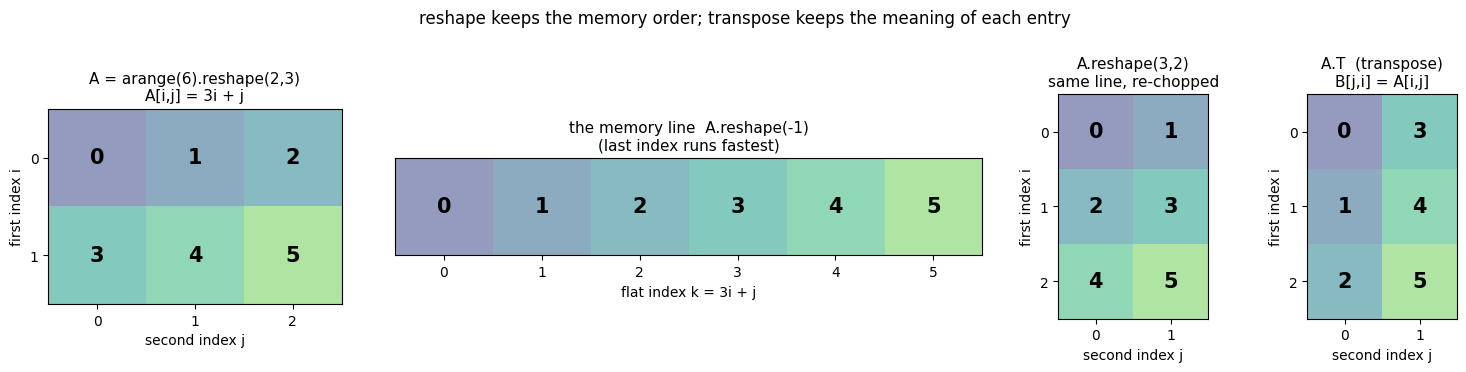

A.reshape(3,2).ravel() = [0 1 2 3 4 5]   <- unchanged memory line
A.T.ravel()            = [0 3 1 4 2 5]   <- a different order: entries were permuted


In [13]:
# ==============================================================================
# FIGURE: memory line, reshape and transpose of a (2,3) array
# ==============================================================================
def show_array(ax, arr, title, xlabel="second index j", ylabel="first index i"):
    """Draw a 2D integer array as a coloured grid with the VALUE written in each cell."""
    arr = np.atleast_2d(arr)
    ax.imshow(arr, cmap="viridis", vmin=-2, vmax=arr.max() + 2, alpha=0.55)
    for (r, c), val in np.ndenumerate(arr):
        ax.text(c, r, str(val), ha="center", va="center", fontsize=15, fontweight="bold")
    ax.set_xticks(range(arr.shape[1]))
    ax.set_yticks(range(arr.shape[0]))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)


A23 = np.arange(6).reshape(2, 3)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), gridspec_kw={"width_ratios": [3, 6, 2, 2]})
show_array(axes[0], A23, "A = arange(6).reshape(2,3)\nA[i,j] = 3i + j")
show_array(axes[1], A23.reshape(1, -1), "the memory line  A.reshape(-1)\n(last index runs fastest)",
           xlabel="flat index k = 3i + j", ylabel="")
axes[1].set_yticks([])
show_array(axes[2], A23.reshape(3, 2), "A.reshape(3,2)\nsame line, re-chopped")
show_array(axes[3], A23.T, "A.T  (transpose)\nB[j,i] = A[i,j]")
fig.suptitle("reshape keeps the memory order; transpose keeps the meaning of each entry", y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

print("A.reshape(3,2).ravel() =", A23.reshape(3, 2).ravel(), "  <- unchanged memory line")
print("A.T.ravel()            =", A23.T.ravel(), "  <- a different order: entries were permuted")
assert not np.array_equal(A23.reshape(3, 2), A23.T)

In the third panel the numbers still read $0,1,2,3,4,5$ row by row (same memory line, new chopping: the entry "2" moved
from position $[0,2]$ to $[1,0]$). In the fourth panel each entry kept its *pair of indices* (the entry "2" went from $[0,2]$
to $[2,0]$), and the row-by-row reading order became $0,3,1,4,2,5$.

> **Common pitfall.** If a shape "comes out wrong", never fix it with `reshape` alone. Ask: *which index is which?*
> If indices have to change places, that is a `transpose` (or an einsum with permuted output letters). `reshape` is only for
> **merging adjacent indices or splitting a composite one**. The safe recipe for merging non-adjacent indices is always
> **transpose first, reshape second**.

> **Implementation note.** In NumPy `transpose` returns a *view* with permuted strides (no data moved) and a later `reshape`
> silently makes the copy. JAX hides this distinction completely; the semantics -- which entry ends up where -- are identical, and that is all we rely on.
> (Fortran and MATLAB use the opposite, column-major order, in which the *first* index runs fastest. When you compare
> with code written in such languages, the flat-index convention of Eq. (3) is reversed.)

## 6. Warm-up with three indices: contraction of a tensor with a matrix

Before turning to composite indices, one contraction that involves a rank-3 tensor. Take $T_{xbz}$ with shape $(2,3,4)$ and a
$5\times3$ matrix $M_{ab}$, and contract the **middle** index of $T$ with the column index of $M$:

$$ T'_{xaz}=\sum_{b} M_{ab}\,T_{xbz}. \tag{4}$$

The einsum string is read off directly: `"ab,xbz->xaz"`. There is no equally direct NumPy built-in -- this is where
einsum starts to pay off. As an independent reference we use the fact that for fixed $x$ and $z$ Eq. (4) is an ordinary
matrix-vector product applied to the "fibre" $T_{x\,:\,z}$.

In [14]:
# ==============================================================================
# MATRIX ACTING ON THE MIDDLE INDEX OF A RANK-3 TENSOR     T'_xaz = sum_b M_ab T_xbz
# ==============================================================================
T = rng.normal(size=(2, 3, 4))
M = rng.normal(size=(5, 3))

Tp_loop = np.zeros((2, 5, 4))
for x_ in range(2):
    for a_ in range(5):
        for z_ in range(4):
            for b_ in range(3):                    # the only summed index
                Tp_loop[x_, a_, z_] += M[a_, b_] * T[x_, b_, z_]

Tp_einsum = np.einsum("ab,xbz->xaz", M, T)

Tp_fibres = np.zeros((2, 5, 4))                    # reference: matrix-vector product fibre by fibre
for x_ in range(2):
    for z_ in range(4):
        Tp_fibres[x_, :, z_] = M @ T[x_, :, z_]

check("middle index: loops  vs fibre-wise M @ T[x,:,z]", Tp_loop, Tp_fibres)
check("middle index: einsum vs fibre-wise M @ T[x,:,z]", Tp_einsum, Tp_fibres)
check("middle index: naive_einsum vs np.einsum", naive_einsum("ab,xbz->xaz", M, T), Tp_einsum)

middle index: loops  vs fibre-wise M @ T[x,:,z]      max|diff| = 4.4e-16
middle index: einsum vs fibre-wise M @ T[x,:,z]      max|diff| = 4.4e-16
middle index: naive_einsum vs np.einsum              max|diff| = 0.0e+00


Remember the string `"ab,xbz->xaz"`. With $M$ a $2\times2$ matrix and $T$ of shape $(2,2,2)$ this is *exactly* how an operator acts on the
middle spin of a three-spin chain (Section 16 and notebook [05_matrix_free_operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb)).

## 7. Composite indices: a $4\times4$ matrix *is* a $(2,2,2,2)$ tensor

Consider a system made of two parts $A$ and $B$ with dimensions $d_A$ and $d_B$ (two spins: $d_A=d_B=2$). Its basis states are
labelled by **pairs** $(a,b)$, and a vector of the composite system has components $v_{ab}$ -- a $(d_A,d_B)$ array. To use
ordinary linear algebra we number the pairs with a single composite index, and C-ordering (Eq. 2) does that for us:

$$ I=(a,b)\equiv a\,d_B+b,\qquad\qquad v_I = v_{ab}\ \ \Longleftrightarrow\ \ \texttt{v.reshape(dA*dB)} \leftrightarrow \texttt{v.reshape(dA,dB)}.$$

An operator on the composite system is a matrix $M_{IJ}$ with a composite **row** index $I=(a,b)$ and a composite **column**
index $J=(c,d)$. Splitting both gives a rank-4 tensor,

$$ M_{IJ}=M_{(ab),(cd)}\equiv T_{abcd},\qquad \texttt{T = M.reshape(dA, dB, dA, dB)},\qquad I=a\,d_B+b,\;\; J=c\,d_B+d. \tag{5}$$

**Convention used in the whole course:** in $T_{abcd}$ the *first half* of the indices $(a,b)$ are the row (output) indices,
the *second half* $(c,d)$ are the column (input) indices; within each half, the first letter belongs to subsystem $A$ (the most significant "digit").

Eq.(5) verified for all 16 entries;  example: T[1,0,0,1] = 9 = M[2,1] = 9
and back: T.reshape(4,4) = M                         max|diff| = 0.0e+00


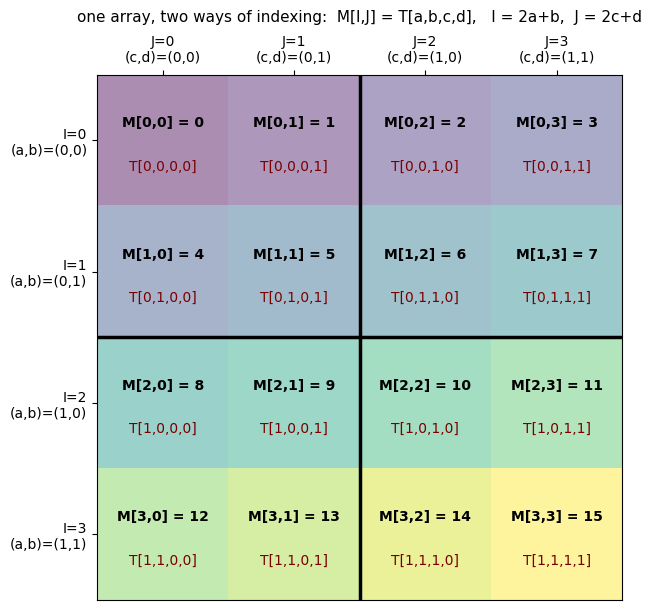

In [15]:
# ==============================================================================
# (4,4) MATRIX  <->  (2,2,2,2) TENSOR
# ==============================================================================
dA, dB = 2, 2
M = np.arange(16).reshape(4, 4)        # M[I,J] = 4I + J : every entry shows its own position
T = M.reshape(dA, dB, dA, dB)          # T[a,b,c,d] = M[a*dB+b, c*dB+d]

for a_, b_, c_, d_ in itertools.product(range(dA), range(dB), range(dA), range(dB)):
    assert T[a_, b_, c_, d_] == M[a_ * dB + b_, c_ * dB + d_]
print("Eq.(5) verified for all 16 entries;  example: T[1,0,0,1] =", T[1, 0, 0, 1], "= M[2,1] =", M[2, 1])
check("and back: T.reshape(4,4) = M", T.reshape(4, 4), M)

# ------------------------------------------------------------------------------
# FIGURE: the 4x4 matrix with its composite labels
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.imshow(M, cmap="viridis", alpha=0.45)
for (I, J), val in np.ndenumerate(M):
    a_, b_ = divmod(I, dB)
    c_, d_ = divmod(J, dB)
    ax.text(J, I - 0.13, f"M[{I},{J}] = {val}", ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(J, I + 0.2, f"T[{a_},{b_},{c_},{d_}]", ha="center", va="center", fontsize=10, color="#7a0000")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels([f"J={J}\n(c,d)=({J // 2},{J % 2})" for J in range(4)])
ax.set_yticklabels([f"I={I}\n(a,b)=({I // 2},{I % 2})" for I in range(4)])
ax.xaxis.tick_top()
ax.axhline(1.5, color="k", lw=2.5); ax.axvline(1.5, color="k", lw=2.5)       # 2x2 block structure: fixed (a,c)
ax.set_title("one array, two ways of indexing:  M[I,J] = T[a,b,c,d],   I = 2a+b,  J = 2c+d", fontsize=11, pad=38)
plt.tight_layout()
plt.show()

The thick lines separate the four $2\times2$ **blocks**: inside a block the "slow" indices $(a,c)$ are fixed and the "fast"
indices $(b,d)$ run. So `T[a,:,c,:]` *is* block $(a,c)$ of the matrix. Keep this picture in mind for the next section.

> **Physics insight.** For two spins, $a$ and $c$ are the output and input states of spin 0, $b$ and $d$ those of spin 1. The entry
> $T_{abcd}$ is the amplitude for the transition $|c\,d\rangle\to|a\,b\rangle$. Nothing is lost or gained by the reshape -- but in
> the tensor form we can address *each spin's* indices separately, which is what locality of physical interactions demands.

## 8. The Kronecker product as einsum + reshape

If $A$ acts on subsystem $A$ and $B$ on subsystem $B$, the operator "$A$ on the first **and** $B$ on the second" is the
**Kronecker (tensor) product** $A\otimes B$ (Nielsen and Chuang, Sec. 2.1.7). Its definition in components is simply "multiply the two matrix elements":

$$ (A\otimes B)_{(a c),(b d)} = A_{ab}\,B_{cd}. \tag{6}$$

Mind the index positions: the row index of $A\otimes B$ is the composite of the two **row** indices $(a,c)$, the column index the composite of the two
**column** indices $(b,d)$. The letters are assigned per *factor* here, not per half as in Eq. (5): $a,b$ are the row and column index of $A$,
$c,d$ those of $B$. As a rank-4 tensor in the convention of Eq. (5) -- rows first, then columns -- the product is
$K_{a c b d}=A_{ab}B_{cd}$: an outer product (no summed index) with a **permutation of indices**, followed by a reshape that merges $(a,c)$ and $(b,d)$:

```python
K = np.einsum("ab,cd->acbd", A, B).reshape(dA_rows * dB_rows, dA_cols * dB_cols)
```

Equivalently, in block form, $A\otimes B=\begin{pmatrix}A_{00}B & A_{01}B\\ A_{10}B & A_{11}B\end{pmatrix}$: block $(a,b)$ is the whole matrix $B$ multiplied by the number $A_{ab}$, consistent with the block picture of Section 7.
We test with *rectangular* matrices of all-different sizes, so that any index mix-up changes a shape or a number.

In [16]:
# ==============================================================================
# KRONECKER PRODUCT   (A (x) B)_{(ac),(bd)} = A_ab B_cd        "ab,cd->acbd" + reshape
# ==============================================================================
A = rng.normal(size=(2, 3))            # a: 2 rows, b: 3 columns
B = rng.normal(size=(4, 5))            # c: 4 rows, d: 5 columns

# (b) four loops; the composite indices are computed by hand with Eq. (2)
K_loop = np.zeros((2 * 4, 3 * 5))
for a_ in range(2):
    for b_ in range(3):
        for c_ in range(4):
            for d_ in range(5):
                K_loop[a_ * 4 + c_, b_ * 5 + d_] = A[a_, b_] * B[c_, d_]

# (c) einsum puts the indices in the order (row_A, row_B, col_A, col_B); reshape merges the pairs
K_einsum = np.einsum("ab,cd->acbd", A, B).reshape(2 * 4, 3 * 5)

check("kron: loops  vs np.kron", K_loop, np.kron(A, B))
check("kron: einsum vs np.kron", K_einsum, np.kron(A, B))

# The WRONG index order: same numbers, same final shape, different matrix.
K_wrong = np.einsum("ab,cd->abcd", A, B).reshape(2 * 4, 3 * 5)
print("'ab,cd->abcd' + reshape equals kron?", np.allclose(K_wrong, np.kron(A, B)), "  <- no error message, just a wrong matrix")

# vectors: (u (x) w)_(ac) = u_a w_c  -> outer product + reshape
u, w = rng.normal(size=3), rng.normal(size=4)
check("kron of vectors: 'a,c->ac' + reshape vs np.kron", np.einsum("a,c->ac", u, w).reshape(-1), np.kron(u, w))

# three factors: rows (a,c,e), columns (b,d,f)
C = rng.normal(size=(2, 2))
K3 = np.einsum("ab,cd,ef->acebdf", A, B, C).reshape(2 * 4 * 2, 3 * 5 * 2)
check("kron of three: one einsum vs np.kron(np.kron(A,B),C)", K3, np.kron(np.kron(A, B), C))

kron: loops  vs np.kron                              max|diff| = 0.0e+00
kron: einsum vs np.kron                              max|diff| = 0.0e+00
'ab,cd->abcd' + reshape equals kron? False   <- no error message, just a wrong matrix
kron of vectors: 'a,c->ac' + reshape vs np.kron      max|diff| = 0.0e+00
kron of three: one einsum vs np.kron(np.kron(A,B),C) max|diff| = 0.0e+00


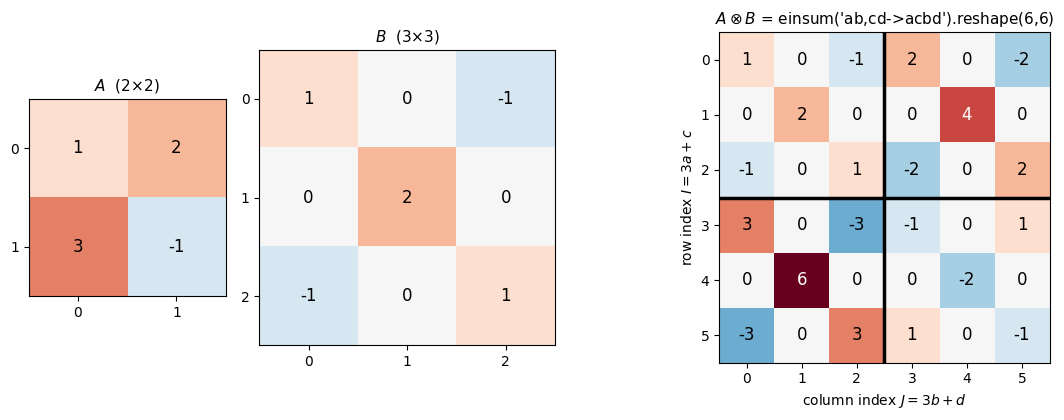

In [17]:
# ==============================================================================
# FIGURE: block structure of the Kronecker product
# ==============================================================================
A_small = np.array([[1, 2], [3, -1]])
B_small = np.array([[1, 0, -1], [0, 2, 0], [-1, 0, 1]])
K_small = np.einsum("ab,cd->acbd", A_small, B_small).reshape(6, 6)
assert np.array_equal(K_small, np.kron(A_small, B_small))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), gridspec_kw={"width_ratios": [2, 3, 6]})
for ax, mat, title in zip(axes, (A_small, B_small, K_small),
                          (r"$A$  (2$\times$2)", r"$B$  (3$\times$3)", r"$A\otimes B$ = einsum('ab,cd->acbd').reshape(6,6)")):
    ax.imshow(mat, cmap="RdBu_r", vmin=-6, vmax=6)
    for (r, c_), val in np.ndenumerate(mat):
        ax.text(c_, r, str(val), ha="center", va="center", fontsize=12, color="w" if abs(val) >= 4 else "k")
    ax.set_xticks(range(mat.shape[1])); ax.set_yticks(range(mat.shape[0]))
    ax.set_title(title, fontsize=11)
axes[2].axhline(2.5, color="k", lw=2.5); axes[2].axvline(2.5, color="k", lw=2.5)
axes[2].set_xlabel(r"column index $J = 3b + d$"); axes[2].set_ylabel(r"row index $I = 3a + c$")
plt.tight_layout()
plt.show()

The right panel shows the block structure: the upper-left block is $A_{00}B=1\cdot B$, the upper-right $A_{01}B=2B$, the lower-left $3B$ and
the lower-right $-B$. The "slow" composite digit belongs to the **left** factor.

### 8.1 The central trick of this course: never build $A\otimes B$

How does $A\otimes B$ act on a vector $v$ of the composite system? Write $v_J=v_{bd}$ as a $(d_A,d_B)$ array $V$. Then

$$ \big[(A\otimes B)\,v\big]_{(ac)}=\sum_{b,d}A_{ab}\,B_{cd}\,V_{bd} \qquad\Longleftrightarrow\qquad \texttt{einsum("ab,cd,bd->ac", A, B, V)}. \tag{7}$$

The big matrix never appears: $A$ is contracted with the first index of $V$, $B$ with the second. In matrix language
Eq. (7) is $A\,V B^{T}$ -- we use this as the independent check. For $N$ spins the saving is the difference between $4^N$ and $\sim 2^N$ numbers.

In [18]:
# ==============================================================================
# (A (x) B) v   WITHOUT building A (x) B
# ==============================================================================
A = rng.normal(size=(3, 3))
B = rng.normal(size=(4, 4))
v = rng.normal(size=3 * 4)             # a generic vector of the composite system (NOT a product u (x) w)
V = v.reshape(3, 4)                    # the same numbers with two indices  V[b,d]

w_dense = np.kron(A, B) @ v                                   # textbook: build the 12x12 matrix, multiply
w_einsum = np.einsum("ab,cd,bd->ac", A, B, V).reshape(-1)     # Eq. (7): contract each factor with "its" index
w_matrix = (A @ V @ B.T).reshape(-1)                          # the same in matrix language

check("(A(x)B)v: einsum 'ab,cd,bd->ac' vs dense kron", w_einsum, w_dense)
check("(A(x)B)v: A V B^T            vs dense kron", w_matrix, w_dense)

# special case B = identity: "A acts on the first subsystem only" -- just contract the first index
check("(A(x)1)v: einsum 'ab,bd->ad'  vs dense kron", np.einsum("ab,bd->ad", A, V).reshape(-1), np.kron(A, np.eye(4)) @ v)

(A(x)B)v: einsum 'ab,cd,bd->ac' vs dense kron        max|diff| = 1.1e-15
(A(x)B)v: A V B^T            vs dense kron           max|diff| = 1.6e-15
(A(x)1)v: einsum 'ab,bd->ad'  vs dense kron          max|diff| = 8.9e-16


> **Physics insight.** The last line is the prototype of *every* local operation in a many-body simulation: an operator that
> acts on one subsystem is a contraction with that subsystem's index; the identity on the rest of the system costs
> nothing, because indices that are not mentioned are simply left alone.

## 9. Traces and partial traces

The trace sums the diagonal, $\mathrm{Tr}\,M=\sum_I M_{II}$. With composite indices $I=(a,b)$ this reads
$\sum_{ab}T_{abab}$, i.e. `"abab->"`: the row and column index of *each* subsystem are tied together.

The **partial trace** ties together the row and column indices of **only one** subsystem and leaves the other pair open:

$$ \big(\mathrm{Tr}_B M\big)_{ac}=\sum_{b} T_{a\,b\,c\,b}\quad\texttt{"abcb->ac"},\qquad\qquad
   \big(\mathrm{Tr}_A M\big)_{bd}=\sum_{a} T_{a\,b\,a\,d}\quad\texttt{"abad->bd"}. \tag{8}$$

The result is an operator on the remaining subsystem ($d_A\times d_A$ or $d_B\times d_B$). In the block picture of Section 7,
$\mathrm{Tr}_B$ replaces each block by its trace. In quantum mechanics the partial trace is the operation of *ignoring* a subsystem;
it produces the reduced density matrix (Nielsen and Chuang, Sec. 2.4.3) that you will meet in
[06_states_observables_entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb). Here we treat it purely as an index operation.

Independent references: (i) `np.trace(T, axis1=1, axis2=3)`, which sums the diagonal over a chosen pair of axes; (ii) the identities
$\mathrm{Tr}_B(A\otimes B)=A\cdot\mathrm{Tr}B$, $\mathrm{Tr}_A(A\otimes B)=\mathrm{Tr}A\cdot B$ and $\mathrm{Tr}(\mathrm{Tr}_B M)=\mathrm{Tr}M$.

In [19]:
# ==============================================================================
# PARTIAL TRACES of a matrix on a (dA x dB)-dimensional composite space
# ==============================================================================
dA, dB = 2, 3                          # different dimensions on purpose
M = rng.normal(size=(dA * dB, dA * dB))
T = M.reshape(dA, dB, dA, dB)          # T[a,b,c,d]: rows (a,b), columns (c,d)

# (b) loops
trB_loop = np.zeros((dA, dA))
for a_ in range(dA):
    for c_ in range(dA):
        for b_ in range(dB):
            trB_loop[a_, c_] += T[a_, b_, c_, b_]      # same b on the row side and on the column side

trA_loop = np.zeros((dB, dB))
for b_ in range(dB):
    for d_ in range(dB):
        for a_ in range(dA):
            trA_loop[b_, d_] += T[a_, b_, a_, d_]

# (c) einsum, (d) NumPy reference
trB = np.einsum("abcb->ac", T)
trA = np.einsum("abad->bd", T)
check("Tr_B: loops  vs np.trace(T, axis1=1, axis2=3)", trB_loop, np.trace(T, axis1=1, axis2=3))
check("Tr_B: einsum vs np.trace(T, axis1=1, axis2=3)", trB, np.trace(T, axis1=1, axis2=3))
check("Tr_A: loops  vs np.trace(T, axis1=0, axis2=2)", trA_loop, np.trace(T, axis1=0, axis2=2))
check("Tr_A: einsum vs np.trace(T, axis1=0, axis2=2)", trA, np.trace(T, axis1=0, axis2=2))

# full trace three ways
check("Tr M = 'abab->'", np.einsum("abab->", T), np.trace(M))
check("Tr(Tr_B M) = Tr M", np.trace(trB), np.trace(M))
check("Tr(Tr_A M) = Tr M", np.trace(trA), np.trace(M))

# product operators: Tr_B (A (x) B) = A Tr(B),   Tr_A (A (x) B) = Tr(A) B
A = rng.normal(size=(dA, dA))
B = rng.normal(size=(dB, dB))
TK = np.kron(A, B).reshape(dA, dB, dA, dB)
check("Tr_B(A(x)B) = A Tr(B)", np.einsum("abcb->ac", TK), A * np.trace(B))
check("Tr_A(A(x)B) = Tr(A) B", np.einsum("abad->bd", TK), np.trace(A) * B)

# a string that ties a row index of B to a COLUMN index of A is caught by the length mismatch (dB=3 vs dA=2)
try:
    np.einsum("abbc->ac", T)
except ValueError as err:
    print("'abbc->ac' -> ValueError:", str(err)[:75])

Tr_B: loops  vs np.trace(T, axis1=1, axis2=3)        max|diff| = 0.0e+00
Tr_B: einsum vs np.trace(T, axis1=1, axis2=3)        max|diff| = 0.0e+00
Tr_A: loops  vs np.trace(T, axis1=0, axis2=2)        max|diff| = 0.0e+00
Tr_A: einsum vs np.trace(T, axis1=0, axis2=2)        max|diff| = 0.0e+00
Tr M = 'abab->'                                      max|diff| = 0.0e+00
Tr(Tr_B M) = Tr M                                    max|diff| = 0.0e+00
Tr(Tr_A M) = Tr M                                    max|diff| = 0.0e+00
Tr_B(A(x)B) = A Tr(B)                                max|diff| = 2.2e-16
Tr_A(A(x)B) = Tr(A) B                                max|diff| = 2.2e-16
'abbc->ac' -> ValueError: dimensions in operand 0 for collapsing index 'b' don't match (3 != 2)


All identities hold to machine precision. The choice $d_A\neq d_B$ protects us: interchanging the strings `"abcb->ac"` and `"abad->bd"`
would give a matrix of the wrong *shape*, and a string like `"abbc->ac"` (tying a row index of $B$ to a column index of $A$) raises the error printed
above, because the letter `b` is given the lengths 3 and 2 at once. With $d_A=d_B$ both mistakes would run silently.

## 10. Tensor-network diagrams: drawing instead of writing indices

Long index expressions are hard to read. Physicists therefore *draw* them (the notation goes back to Penrose):

* a **tensor** is a shape (here: a circle) with one **leg** per index -- a vector has one leg, a matrix two, a rank-3 tensor three;
* a leg that **connects two tensors** is a shared, summed index (Rules 1 and 3): a **contraction**;
* a leg with a **free end** is a free index of the result (Rule 2).

So the rank of the result can be read off by counting open legs, and an einsum string is nothing but a *list of the legs*:
each tensor lists the labels of its legs, the output lists the open ones. The figure shows the operations of this notebook as diagrams.

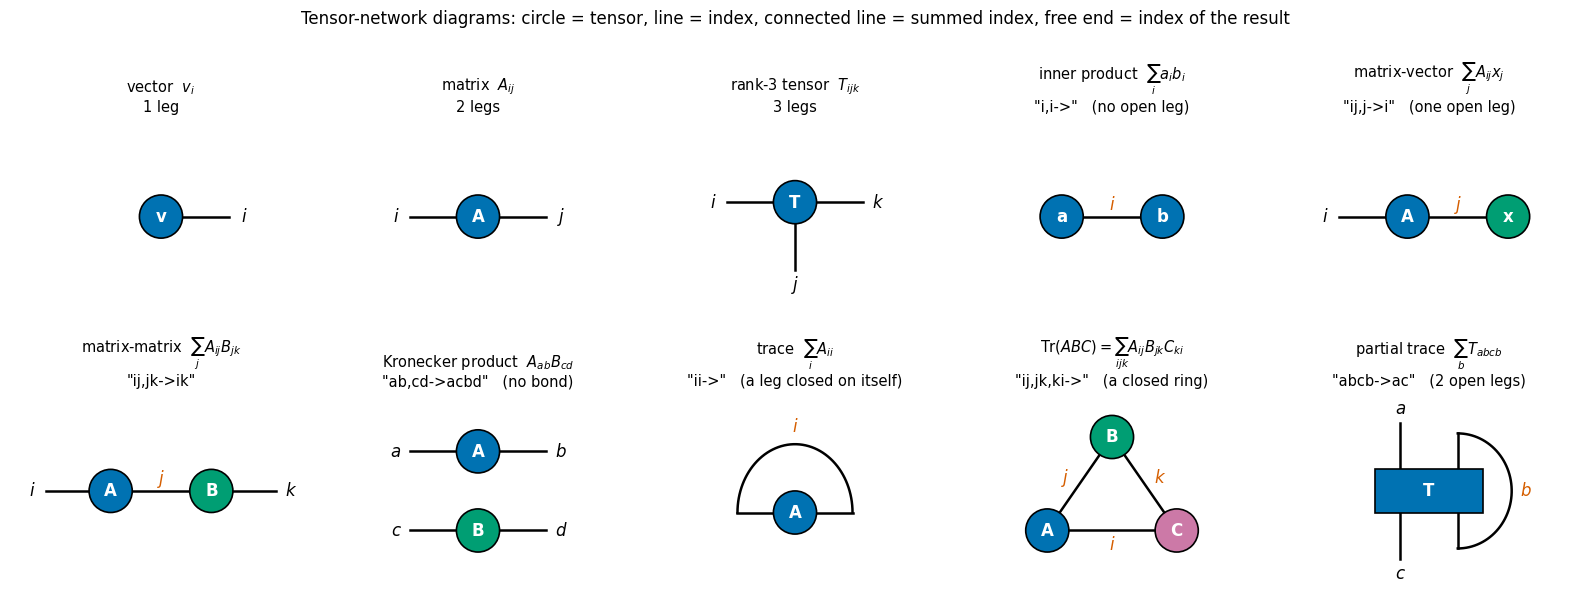

In [20]:
# ==============================================================================
# FIGURE: tensor-network diagrams for the contractions of this notebook
# ==============================================================================
C_BLUE, C_ORANGE, C_GREEN, C_PINK = "#0072B2", "#D55E00", "#009E73", "#CC79A7"    # colour-blind-friendly palette


def draw_node(ax, x, y, name, color=C_BLUE, r=0.30):
    """A tensor: a filled circle with its name."""
    ax.add_patch(plt.Circle((x, y), r, facecolor=color, edgecolor="k", lw=1.2, zorder=3))
    ax.text(x, y, name, ha="center", va="center", fontsize=12, color="w", fontweight="bold", zorder=4)


def draw_leg(ax, p, q, label="", open_end=False, offset=(0.0, 0.17)):
    """A leg (index) from point p to point q.  Open legs carry their label beyond the free end q;
    contracted legs (bonds) carry it next to the midpoint."""
    ax.plot([p[0], q[0]], [p[1], q[1]], "-", color="k", lw=1.8, zorder=1)
    if open_end:
        d = np.array(q) - np.array(p)
        pos = np.array(q) + 0.2 * d / np.linalg.norm(d)
        ax.text(pos[0], pos[1], label, ha="center", va="center", fontsize=12, style="italic")
    else:
        mid = (np.array(p) + np.array(q)) / 2 + np.array(offset)
        ax.text(mid[0], mid[1], label, ha="center", va="center", fontsize=12, style="italic", color=C_ORANGE)


def new_panel(ax, title):
    ax.set_xlim(-2.1, 2.1); ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=10.5)


fig, axes = plt.subplots(2, 5, figsize=(16, 6.4))
ax = axes[0, 0]; new_panel(ax, "vector  $v_i$\n1 leg")
draw_node(ax, 0, 0, "v"); draw_leg(ax, (0, 0), (0.95, 0), "i", open_end=True)

ax = axes[0, 1]; new_panel(ax, "matrix  $A_{ij}$\n2 legs")
draw_node(ax, 0, 0, "A"); draw_leg(ax, (0, 0), (-0.95, 0), "i", True); draw_leg(ax, (0, 0), (0.95, 0), "j", True)

ax = axes[0, 2]; new_panel(ax, "rank-3 tensor  $T_{ijk}$\n3 legs")
draw_node(ax, 0, 0.2, "T"); draw_leg(ax, (0, 0.2), (-0.95, 0.2), "i", True)
draw_leg(ax, (0, 0.2), (0, -0.75), "j", True); draw_leg(ax, (0, 0.2), (0.95, 0.2), "k", True)

ax = axes[0, 3]; new_panel(ax, "inner product  $\\sum_i a_i b_i$\n\"i,i->\"   (no open leg)")
draw_node(ax, -0.7, 0, "a"); draw_node(ax, 0.7, 0, "b"); draw_leg(ax, (-0.7, 0), (0.7, 0), "i")

ax = axes[0, 4]; new_panel(ax, "matrix-vector  $\\sum_j A_{ij}x_j$\n\"ij,j->i\"   (one open leg)")
draw_node(ax, -0.3, 0, "A"); draw_node(ax, 1.1, 0, "x", C_GREEN)
draw_leg(ax, (-0.3, 0), (-1.25, 0), "i", True); draw_leg(ax, (-0.3, 0), (1.1, 0), "j")

ax = axes[1, 0]; new_panel(ax, "matrix-matrix  $\\sum_j A_{ij}B_{jk}$\n\"ij,jk->ik\"")
draw_node(ax, -0.7, 0, "A"); draw_node(ax, 0.7, 0, "B", C_GREEN)
draw_leg(ax, (-0.7, 0), (-1.6, 0), "i", True); draw_leg(ax, (-0.7, 0), (0.7, 0), "j"); draw_leg(ax, (0.7, 0), (1.6, 0), "k", True)

ax = axes[1, 1]; new_panel(ax, "Kronecker product  $A_{ab}B_{cd}$\n\"ab,cd->acbd\"   (no bond)")
for y0, name, col, l1, l2 in ((0.55, "A", C_BLUE, "a", "b"), (-0.55, "B", C_GREEN, "c", "d")):
    draw_node(ax, 0, y0, name, col); draw_leg(ax, (0, y0), (-0.95, y0), l1, True); draw_leg(ax, (0, y0), (0.95, y0), l2, True)

ax = axes[1, 2]; new_panel(ax, "trace  $\\sum_i A_{ii}$\n\"ii->\"   (a leg closed on itself)")
draw_node(ax, 0, -0.3, "A")
ax.plot([-0.8, 0.8], [-0.3, -0.3], "k-", lw=1.8, zorder=1)
t_ = np.linspace(0, np.pi, 60)
ax.plot(0.8 * np.cos(t_), -0.3 + 0.95 * np.sin(t_), "k-", lw=1.8, zorder=1)
ax.text(0, 0.82, "i", ha="center", fontsize=12, style="italic", color=C_ORANGE)

ax = axes[1, 3]; new_panel(ax, "Tr$(ABC)=\\sum_{ijk} A_{ij}B_{jk}C_{ki}$\n\"ij,jk,ki->\"   (a closed ring)")
pA, pB, pC = (-0.9, -0.55), (0.0, 0.75), (0.9, -0.55)
draw_node(ax, *pA, "A"); draw_node(ax, *pB, "B", C_GREEN); draw_node(ax, *pC, "C", C_PINK)
draw_leg(ax, pA, pB, "j", offset=(-0.2, 0.08)); draw_leg(ax, pB, pC, "k", offset=(0.2, 0.08)); draw_leg(ax, pC, pA, "i", offset=(0, -0.2))

ax = axes[1, 4]; new_panel(ax, "partial trace  $\\sum_b T_{abcb}$\n\"abcb->ac\"   (2 open legs)")
ax.add_patch(plt.Rectangle((-0.75, -0.3), 1.5, 0.6, facecolor=C_BLUE, edgecolor="k", lw=1.2, zorder=3))
ax.text(0, 0, "T", ha="center", va="center", fontsize=12, color="w", fontweight="bold", zorder=4)
draw_leg(ax, (-0.4, 0.3), (-0.4, 0.95), "a", True); draw_leg(ax, (-0.4, -0.3), (-0.4, -0.95), "c", True)
ax.plot([0.4, 0.4], [0.3, 0.8], "k-", lw=1.8); ax.plot([0.4, 0.4], [-0.3, -0.8], "k-", lw=1.8)
t_ = np.linspace(-np.pi / 2, np.pi / 2, 60)
ax.plot(0.4 + 0.75 * np.cos(t_), 0.8 * np.sin(t_), "k-", lw=1.8, zorder=1)
ax.text(1.35, 0, "b", ha="center", va="center", fontsize=12, style="italic", color=C_ORANGE)

fig.suptitle("Tensor-network diagrams: circle = tensor, line = index, connected line = summed index, free end = index of the result",
             fontsize=12, y=1.0)
plt.tight_layout()
plt.show()

Reading the figure: the inner product and $\mathrm{Tr}(ABC)$ have **no open legs**, so they are numbers; the matrix-vector product has one
open leg (a vector); the matrix product and the partial trace have two (matrices); the Kronecker product has four open legs and
**no bond** -- it is an outer product, and only the subsequent `reshape` bundles the legs $(a,c)$ and $(b,d)$ into the two thick legs of a big matrix.
In the partial-trace panel the upper legs of $T$ are the row indices $(a,b)$, the lower ones the column indices $(c,d)$; the legs of subsystem $B$ are joined.

> **Physics insight.** Diagrams of this kind are the daily language of *tensor-network* methods (introductions: Bridgeman and Chubb 2017;
> Orús 2014), which you will meet in
> [notebook 18 (Chapter 7)](../ch07_tensor_networks/18_mps_tebd.ipynb) (matrix product states). A diagram fixes *what* is
> contracted; it says nothing about the *order* in which a computer should do the sums. That is a separate question with large practical consequences (Section 12).

## 11. Batched contractions

Often the same operation must be done for many independent inputs: many matrices, many vectors, many samples. In index
notation this is one extra index that is **shared by the inputs and kept in the output** -- by Rules 2 and 3 it is never summed; it just "rides along":

$$ C_{\beta ik}=\sum_j A_{\beta ij}B_{\beta jk}\quad\texttt{"bij,bjk->bik"},\qquad\qquad q_\beta=\sum_{ij}x_{\beta i}\,A_{ij}\,x_{\beta j}\quad\texttt{"bi,ij,bj->b"}.$$

NumPy's `@` follows the same philosophy: for arrays with more than two axes it multiplies the matrices in the *last two*
axes and treats all leading axes as batch axes.

In [21]:
# ==============================================================================
# BATCHED CONTRACTIONS
# ==============================================================================
nb = 6                                                  # batch size
Ab = rng.normal(size=(nb, 3, 4))
Bb = rng.normal(size=(nb, 4, 5))

Cb_loop = np.zeros((nb, 3, 5))
for beta in range(nb):                                  # the batch index: free, never summed
    for i in range(3):
        for k in range(5):
            for j in range(4):
                Cb_loop[beta, i, k] += Ab[beta, i, j] * Bb[beta, j, k]

check("batched matmul: loops  vs Ab @ Bb", Cb_loop, Ab @ Bb)
check("batched matmul: einsum vs Ab @ Bb", np.einsum("bij,bjk->bik", Ab, Bb), Ab @ Bb)

# one matrix, a batch of vectors:  y_bi = sum_j A_ij x_bj
A = rng.normal(size=(4, 4))
Xb = rng.normal(size=(nb, 4))
check("matrix on a batch of vectors: 'ij,bj->bi' vs Xb @ A.T", np.einsum("ij,bj->bi", A, Xb), Xb @ A.T)

# a batch of quadratic forms  q_b = x_b^T A x_b
q_ref = np.array([xb @ A @ xb for xb in Xb])            # reference: Python loop over the batch
check("batch of quadratic forms: 'bi,ij,bj->b'", np.einsum("bi,ij,bj->b", Xb, A, Xb), q_ref)

# TWO different batch letters: every A_a is combined with every B_b (an outer product in the batch indices)
cross = np.einsum("aij,bjk->abik", Ab, Bb)
print("'aij,bjk->abik' ->", cross.shape, " while 'bij,bjk->bik' ->", (Ab @ Bb).shape)
check("cross[2,4] = Ab[2] @ Bb[4]", cross[2, 4], Ab[2] @ Bb[4])

# '...' stands for "any number of leading batch axes"
check("ellipsis: '...ij,...jk->...ik'", np.einsum("...ij,...jk->...ik", Ab, Bb), Ab @ Bb)

batched matmul: loops  vs Ab @ Bb                    max|diff| = 8.9e-16
batched matmul: einsum vs Ab @ Bb                    max|diff| = 8.9e-16
matrix on a batch of vectors: 'ij,bj->bi' vs Xb @ A.T max|diff| = 4.4e-16
batch of quadratic forms: 'bi,ij,bj->b'              max|diff| = 6.7e-16
'aij,bjk->abik' -> (6, 6, 3, 5)  while 'bij,bjk->bik' -> (6, 3, 5)
cross[2,4] = Ab[2] @ Bb[4]                           max|diff| = 2.2e-16
ellipsis: '...ij,...jk->...ik'                       max|diff| = 8.9e-16


Compare `"bij,bjk->bik"` with `"aij,bjk->abik"`: in the second string the two batch letters are different, so *every* $A_a$ is
multiplied with *every* $B_b$ (an outer product in the batch indices). One letter changed, a very different computation --
which is why we insist on deriving strings from formulas and testing them on small examples.
In JAX, batching is usually delegated to `jax.vmap`, which adds the batch letter for you (Section 15).

## 12. The cost of a contraction, and the order of operations

### 12.1 Counting

Our `naive_einsum` makes the cost obvious: there is one innermost iteration for **every combination of values of all distinct letters**. Hence

$$ \text{cost of one einsum}\;\sim\;\prod_{\text{distinct letters } \ell} d_\ell .$$

| contraction | string | letters | cost |
|---|---|---|---|
| matrix-vector | `"ij,j->i"` | $i,j$ | $n^2$ |
| matrix-matrix | `"ij,jk->ik"` | $i,j,k$ | $n^3$ |
| outer product | `"i,j->ij"` | $i,j$ | $n^2$ |
| $2\times2$ matrix on one index of a $(2,)^N$ tensor | `"ab,xbz->xaz"` for $N=3$, one letter per axis in general | $N+1$ letters of length 2 | $2^{N+1}=2\cdot 2^N$ |
| dense $2^N\times2^N$ matrix on a $2^N$ vector | `"ij,j->i"` | $i,j$ of length $2^N$ | $4^N$ |

The last two rows are the quantitative content of "matrix-free" and the reason for this whole notebook.
Memory is counted the same way: an array needs the product of the lengths of *its own* letters.

### 12.2 Order of pairwise contractions

With three or more tensors one normally contracts **pairwise**, and the order matters. Take $y=ABv$ for $n\times n$ matrices and a vector:

* $(AB)\,v$: first a matrix-matrix product, cost $n^3$, then matrix-vector, $n^2$;
* $A\,(Bv)$: two matrix-vector products, cost $2n^2$.

Same result (matrix multiplication is associative), but a factor $\sim n/2$ in work. Let us measure it. A note on timing: we repeat each measurement and
keep the *best* time (the one least disturbed by other processes), after one warm-up call.

In [22]:
# ==============================================================================
# TIMING HELPER (works for NumPy and for JAX functions)
# ==============================================================================
def best_time(fn, *args, repeat=5, min_total=0.2):
    """Best wall time of fn(*args) in seconds, after one warm-up call.  The call is repeated at least `repeat`
    times AND until `min_total` seconds have been spent (at most 1000 times), so that fast functions get many
    repetitions.  The minimum is the estimate least disturbed by whatever else the computer is doing.

    JAX dispatches work asynchronously: a call returns before the result is computed.  `jax.block_until_ready`
    waits for the actual result (and is a harmless no-op for NumPy arrays), so the same helper serves both.
    """
    jax.block_until_ready(fn(*args))                    # warm-up (for jitted functions this includes compilation)
    best, count, t_start = float("inf"), 0, time.perf_counter()
    while count < repeat or (time.perf_counter() - t_start < min_total and count < 1000):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        best = min(best, time.perf_counter() - t0)
        count += 1
    return best


# NumPy's matrix products run on a multi-threaded linear-algebra library (BLAS).  For clean SCALING measurements we
# restrict it to one thread (otherwise thread start-up costs and competition with other programs blur small sizes).
# `threadpoolctl` is an optional package; without it the measurements simply run multi-threaded.
try:
    from threadpoolctl import threadpool_limits

    def single_thread():
        return threadpool_limits(limits=1)
except ImportError:
    from contextlib import nullcontext as single_thread

n=  100: (AB)v = A(Bv)                               max|diff| = 1.3e-13
n=  200: (AB)v = A(Bv)                               max|diff| = 4.5e-13


n=  400: (AB)v = A(Bv)                               max|diff| = 1.3e-12


n=  800: (AB)v = A(Bv)                               max|diff| = 2.7e-12


n= 1600: (AB)v = A(Bv)                               max|diff| = 8.6e-12


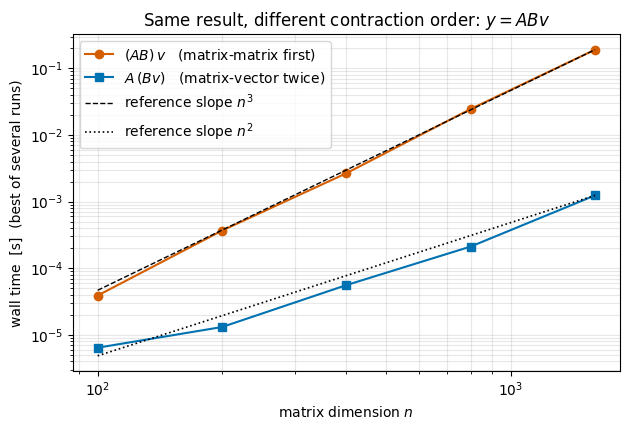

n =   100:  (AB)v     0.039 ms [ 51.3 GFLOP/s]   A(Bv)     0.006 ms [ 6.23 GFLOP/s]   time ratio     6.1   work ratio n/2 =     50
n =   200:  (AB)v     0.368 ms [ 43.5 GFLOP/s]   A(Bv)     0.013 ms [12.20 GFLOP/s]   time ratio    28.0   work ratio n/2 =    100
n =   400:  (AB)v     2.671 ms [ 47.9 GFLOP/s]   A(Bv)     0.056 ms [11.45 GFLOP/s]   time ratio    47.8   work ratio n/2 =    200
n =   800:  (AB)v    24.640 ms [ 41.6 GFLOP/s]   A(Bv)     0.212 ms [12.07 GFLOP/s]   time ratio   116.2   work ratio n/2 =    400
n =  1600:  (AB)v   191.311 ms [ 42.8 GFLOP/s]   A(Bv)     1.242 ms [ 8.25 GFLOP/s]   time ratio   154.1   work ratio n/2 =    800


In [23]:
# ==============================================================================
# EXPERIMENT: (A B) v  versus  A (B v)
# ==============================================================================
# ---------------- PARAMETERS ----------------
sizes = [100, 200, 400, 800, 1600]     # matrix dimension n
# --------------------------------------------
t_left, t_right = [], []
with single_thread():
    for n in sizes:
        A, B, v = rng.normal(size=(n, n)), rng.normal(size=(n, n)), rng.normal(size=n)
        check(f"n={n:5d}: (AB)v = A(Bv)", (A @ B) @ v, A @ (B @ v), tol=1e-6 * n)  # same result up to round-off
        t_left.append(best_time(lambda: (A @ B) @ v, repeat=3))
        t_right.append(best_time(lambda: A @ (B @ v), repeat=3))

sizes_arr = np.array(sizes, dtype=float)
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.loglog(sizes, t_left, "o-", color=C_ORANGE, label=r"$(AB)\,v$   (matrix-matrix first)")
ax.loglog(sizes, t_right, "s-", color=C_BLUE, label=r"$A\,(Bv)$   (matrix-vector twice)")
ax.loglog(sizes, t_left[-1] * (sizes_arr / sizes[-1]) ** 3, "k--", lw=1, label=r"reference slope $n^3$")
ax.loglog(sizes, t_right[-1] * (sizes_arr / sizes[-1]) ** 2, "k:", lw=1.2, label=r"reference slope $n^2$")
ax.set_xlabel(r"matrix dimension $n$"); ax.set_ylabel("wall time  [s]  (best of several runs)")
ax.set_title(r"Same result, different contraction order: $y = ABv$")
ax.grid(True, which="both", alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

# The floating-point rate actually achieved is printed as well: (AB)v does 2n^3 operations, A(Bv) does 2 x 2n^2.
for n, tl, tr in zip(sizes, t_left, t_right):
    print(f"n = {n:5d}:  (AB)v {tl * 1e3:9.3f} ms [{2 * n ** 3 / tl / 1e9:5.1f} GFLOP/s]"
          f"   A(Bv) {tr * 1e3:9.3f} ms [{4 * n ** 2 / tr / 1e9:5.2f} GFLOP/s]   time ratio {tl / tr:7.1f}   work ratio n/2 = {n / 2:6.0f}")
ratio_largest = t_left[-1] / t_right[-1]

Over the whole range the two curves roughly follow the predicted slopes $n^3$ and $n^2$. Between neighbouring points the deviations can be large: the
printed floating-point rates show that neither kernel is equally efficient at all sizes (fixed call overheads at small $n$, cache blocking and
memory traffic at large $n$, competition with other programs). The ratio of the two times grows from a few at $n=100$ to one or two orders of
magnitude at the largest sizes; the exact numbers depend on the machine and on what else it is doing.

The time ratio is the work ratio $n/2$ divided by the ratio of the two printed floating-point rates. A matrix-matrix product reads each matrix
entry once and then uses it $n$ times, so on an otherwise idle processor it reaches a large fraction of the peak rate; a matrix-vector product uses
each entry exactly *once* and is limited by how fast the matrix can be streamed from memory. On a quiet machine the first rate is therefore several
times the second and the time ratio stays well below $n/2$; when other programs compete for the processor and its caches, both rates drop and
their ratio shifts. The result itself does not reveal the wasted factor; counting the operations does.

### 12.3 einsum with three operands

`np.einsum("ij,jk,k->i", A, B, v)` by default (`optimize=False`) evaluates the formula *literally* as one triple loop: cost $n^3$, although no $n\times n$ intermediate is ever stored.
With `optimize=True` NumPy first searches for a good sequence of pairwise contractions -- `True` selects a *greedy* search, `optimize="optimal"` an
exhaustive one; `np.einsum_path` reports what it found.
This path search is the core of the `opt_einsum` package (Smith and Gray 2018), contributed to NumPy in version 1.12.
**`jnp.einsum` always searches for a path**, calling `opt_einsum` directly: its default is `optimize="auto"`, which runs the exhaustive *optimal* search for up to four operands and
cheaper heuristics beyond that. Under `jit` the search happens once, while the function is traced, because the string is ordinary Python data.

In [24]:
# ==============================================================================
# einsum WITH THREE OPERANDS: literal evaluation vs optimized contraction path
# ==============================================================================
n = 300
A, B, v = rng.normal(size=(n, n)), rng.normal(size=(n, n)), rng.normal(size=n)

path, report = np.einsum_path("ij,jk,k->i", A, B, v, optimize="optimal")
print(report)

with single_thread():
    t_literal = best_time(lambda: np.einsum("ij,jk,k->i", A, B, v), repeat=3)
    t_optimal = best_time(lambda: np.einsum("ij,jk,k->i", A, B, v, optimize=True), repeat=3)
    t_manual = best_time(lambda: A @ (B @ v), repeat=3)
print(f"np.einsum, literal triple loop : {t_literal * 1e3:9.3f} ms")
print(f"np.einsum, optimize=True       : {t_optimal * 1e3:9.3f} ms")
print(f"A @ (B @ v) by hand            : {t_manual * 1e3:9.3f} ms")
check("all three agree", np.einsum("ij,jk,k->i", A, B, v, optimize=True), A @ (B @ v), tol=1e-8)
check("jnp.einsum agrees too", jnp.einsum("ij,jk,k->i", A, B, v), A @ (B @ v), tol=1e-8 if PRECISION == "double" else 1e-1)

  Complete contraction:  ij,jk,k->i
         Naive scaling:  3
     Optimized scaling:  2
      Naive FLOP count:  8.100e+07
  Optimized FLOP count:  3.600e+05
   Theoretical speedup:  224.999
  Largest intermediate:  3.000e+02 elements
--------------------------------------------------------------------------
scaling                  current                                remaining
--------------------------------------------------------------------------
   2                     k,jk->j                                  ij,j->i
   2                     j,ij->i                                     i->i


np.einsum, literal triple loop :    42.661 ms
np.einsum, optimize=True       :     0.089 ms
A @ (B @ v) by hand            :     0.031 ms
all three agree                                      max|diff| = 0.0e+00
jnp.einsum agrees too                                max|diff| = 5.7e-14


The report reads: *naive scaling 3* (three letters $\Rightarrow n^3$), *optimized scaling 2*; the optimizer found exactly our order -- first
`k,jk->j` (that is $Bv$), then `j,ij->i`. The measured times confirm that the literal evaluation is slower by orders of magnitude.
(The report above was produced with `optimize="optimal"` and the timing with `optimize=True`; for three operands the greedy and the exhaustive
search return the same path.)

> **Numerical practice.** (i) Before running a big contraction, count letters: the cost is the product of the lengths of all
> distinct letters in each pairwise step, the memory is the size of the largest intermediate. (ii) With NumPy, pass
> `optimize=True` for three or more operands, or split the contraction by hand. (iii) Finding the optimal order for a *large* network
> is a hard combinatorial problem in general -- for the small, chain-like contractions of this course the choice is obvious: **always keep the big state tensor
> as one operand and contract small matrices into it, one after the other.**

## 13. `einsum` vs `tensordot` vs `matmul`

There are three standard tools for contractions. They compute the same sums, and differ in convenience:

| tool | what you specify | order of the output axes | batch indices | traces / repeated letters |
|---|---|---|---|---|
| `A @ B` (`matmul`) | nothing: last axis of `A` with second-to-last of `B` | fixed | leading axes (broadcast) | no |
| `tensordot(A, B, axes=([..],[..]))` | which axes of `A` are summed against which axes of `B` | **fixed: free axes of `A`, then free axes of `B`** | no | no |
| `einsum` | a name for every index | **any** (you write it) | yes | yes |

Because `tensordot` always puts the remaining axes of the first operand first, applying a matrix to the *middle* index of a tensor needs an extra `moveaxis`
to put the new index back in place. A third route uses Section 5: merge everything to the left and everything to the right of the target index into two composite indices,
`T.reshape(left, d, right)`, and let batched `matmul` do the work. All three are compared on a rank-5 tensor, target axis 2.

In [25]:
# ==============================================================================
# THREE WAYS to apply a matrix to axis q of a tensor:   T'_{x y a z w} = sum_b M_ab T_{x y b z w}
# ==============================================================================
dims = (3, 4, 5, 6, 7)
q = 2                                                   # target axis (length 5)
T = rng.normal(size=dims)
M = rng.normal(size=(5, 5))

# (1) einsum: write down the formula
out_einsum = np.einsum("ab,xybzw->xyazw", M, T)

# (2) tensordot: sum axis 1 of M against axis q of T.  Result axes: (a, x, y, z, w)  -> move axis 0 back to position q
out_tensordot = np.moveaxis(np.tensordot(M, T, axes=([1], [q])), 0, q)

# (3) reshape + matmul: (x,y) -> one composite 'left' index, (z,w) -> one composite 'right' index
left, right = int(np.prod(dims[:q])), int(np.prod(dims[q + 1:]))
out_matmul = (M @ T.reshape(left, dims[q], right)).reshape(dims)     # M broadcasts over the leading 'left' axis

check("tensordot + moveaxis  vs einsum", out_tensordot, out_einsum)
check("reshape + matmul      vs einsum", out_matmul, out_einsum)
check("naive_einsum (loops)  vs einsum", naive_einsum("ab,xybzw->xyazw", M, T), out_einsum)

# a quick speed comparison on a larger tensor (about 10^6 entries)
T_big = rng.normal(size=(16,) * 5)
M_big = rng.normal(size=(16, 16))
with single_thread():
    for name, fn in [("einsum", lambda: np.einsum("ab,xybzw->xyazw", M_big, T_big)),
                     ("einsum, optimize=True", lambda: np.einsum("ab,xybzw->xyazw", M_big, T_big, optimize=True)),
                     ("tensordot + moveaxis", lambda: np.moveaxis(np.tensordot(M_big, T_big, axes=([1], [2])), 0, 2)),
                     ("reshape + matmul", lambda: (M_big @ T_big.reshape(256, 16, 256)).reshape((16,) * 5))]:
        print(f"{name:<24s} {best_time(fn, repeat=3) * 1e3:8.2f} ms   (one thread)")

tensordot + moveaxis  vs einsum                      max|diff| = 1.3e-15
reshape + matmul      vs einsum                      max|diff| = 1.3e-15
naive_einsum (loops)  vs einsum                      max|diff| = 0.0e+00


einsum                      13.08 ms   (one thread)


einsum, optimize=True        2.76 ms   (one thread)


tensordot + moveaxis         2.19 ms   (one thread)


reshape + matmul             1.02 ms   (one thread)


All routes give the same numbers to round-off. Plain `np.einsum` is the slowest by a wide margin, because the routes use different kernels:
plain `np.einsum` runs its own
generic loops, whereas `tensordot`, `matmul` and `einsum(..., optimize=True)` hand the work to the optimized matrix-multiplication library (BLAS) after
suitable transposes and reshapes. (In JAX these differences largely disappear, because all of them are lowered to the same XLA operation and compiled.)

**Our choice for this course is einsum**: the string *is* the formula, any index order and any number of target indices are handled uniformly, traces and
batch indices come for free, and -- as the next section shows -- the strings can be generated by a program. Notebook
[05_matrix_free_operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) benchmarks the alternatives carefully for the many-spin case.

## 14. Building einsum strings programmatically

So far we typed every string by hand. A simulator must apply a matrix to index $q$ of a rank-$n$ tensor for *any* $n$ and $q$: the string has
to be **built by code**. A string is just text, so this is ordinary Python string manipulation. The configuration cell
provides the pool of labels `_LETTERS = "abc...xyzABC...XYZ"` (52 letters).

### 14.1 Outer product of $n$ vectors

Target: $T_{ab c\dots}=u^{(0)}_a u^{(1)}_b u^{(2)}_c\cdots$, i.e. the strings `"a,b->ab"`, `"a,b,c->abc"`, ...

In [26]:
# ==============================================================================
# STRING BUILDER 1: outer product of n vectors      "a,b,c->abc"
# ==============================================================================
def outer_string(n):
    """einsum string for the outer product of n vectors.

    MATH   T[a,b,c,...] = u0[a] u1[b] u2[c] ...      (no summed index)
    IMPLEMENTATION   inputs = the first n letters separated by commas, output = the same letters joined.
    """
    letters = _LETTERS[:n]
    return ",".join(letters) + "->" + letters


for n in (2, 3, 5):
    print(f"n = {n}:  '{outer_string(n)}'")

vecs = [rng.normal(size=d) for d in (2, 3, 4, 5)]
T_outer = np.einsum(outer_string(4), *vecs)             # '*vecs' unpacks the list into separate arguments
ref = np.kron(np.kron(np.kron(vecs[0], vecs[1]), vecs[2]), vecs[3]).reshape(2, 3, 4, 5)
check("outer product of 4 vectors vs chained np.kron", T_outer, ref)

n = 2:  'a,b->ab'
n = 3:  'a,b,c->abc'
n = 5:  'a,b,c,d,e->abcde'
outer product of 4 vectors vs chained np.kron        max|diff| = 0.0e+00


### 14.2 A matrix acting on axis $q$ of a rank-$n$ tensor

Target: $T'_{\dots a\dots}=\sum_b M_{ab}T_{\dots b\dots}$ with $b$ at position $q$. The recipe, in words:

1. label the axes of $T$ with the first $n$ letters: `inp = ['a','b','c',...]`;
2. take one **fresh** letter `new` (the next unused one) for the output index of $M$;
3. $M$ carries `new` (row = output) followed by `inp[q]` (column = input, shared with $T$ $\Rightarrow$ summed);
4. the output is `inp` with the letter at position $q$ **replaced** by `new` -- so the new index sits where the old one was.

For $n=3$, $q=1$ this produces `"db,abc->adc"`, which is the string `"ab,xbz->xaz"` of Section 6 with renamed letters.

In [27]:
# ==============================================================================
# STRING BUILDER 2: matrix on axis q of a rank-n tensor
# ==============================================================================
def axis_string(n, q):
    """einsum string for  T'[.., a, ..] = sum_b M[a, b] T[.., b, ..]   (b = axis q of a rank-n tensor)."""
    inp = list(_LETTERS[:n])           # step 1: labels of T
    new = _LETTERS[n]                  # step 2: a fresh label for the new index
    out = inp.copy()
    out[q] = new                       # step 4: replace the target letter in the output
    return f"{new}{inp[q]},{''.join(inp)}->{''.join(out)}"          # step 3: M = (new, old)


def apply_matrix_to_axis(T, M, q):
    """Contract the column index of the matrix M with axis q of the tensor T; the row index of M takes its place.

    MATH   T'[i_0,..,a,..,i_{n-1}] = sum_b M[a,b] T[i_0,..,b,..,i_{n-1}]
    COST   (number of entries of T) x (number of rows of M);  no large matrix is formed.
    """
    return np.einsum(axis_string(T.ndim, q), M, T)


for q in range(3):
    print(f"n = 3, q = {q}:  '{axis_string(3, q)}'")
print(f"n = 6, q = 4:  '{axis_string(6, 4)}'")

# CHECKPOINT: every axis of a tensor with all-different dimensions, against tensordot + moveaxis AND the loop version
T = rng.normal(size=(2, 3, 4, 5))
for q, d in enumerate(T.shape):
    M = rng.normal(size=(d + 1, d))    # rectangular on purpose: the target axis changes its length d -> d+1
    ref = np.moveaxis(np.tensordot(M, T, axes=([1], [q])), 0, q)
    check(f"apply_matrix_to_axis, q={q}: vs tensordot+moveaxis", apply_matrix_to_axis(T, M, q), ref)
    check(f"                      q={q}: vs naive loops", naive_einsum(axis_string(4, q), M, T), ref)

n = 3, q = 0:  'da,abc->dbc'
n = 3, q = 1:  'db,abc->adc'
n = 3, q = 2:  'dc,abc->abd'
n = 6, q = 4:  'ge,abcdef->abcdgf'
apply_matrix_to_axis, q=0: vs tensordot+moveaxis     max|diff| = 4.4e-16
                      q=0: vs naive loops            max|diff| = 4.4e-16
apply_matrix_to_axis, q=1: vs tensordot+moveaxis     max|diff| = 8.9e-16
                      q=1: vs naive loops            max|diff| = 8.9e-16
apply_matrix_to_axis, q=2: vs tensordot+moveaxis     max|diff| = 8.9e-16
                      q=2: vs naive loops            max|diff| = 8.9e-16
apply_matrix_to_axis, q=3: vs tensordot+moveaxis     max|diff| = 8.9e-16
                      q=3: vs naive loops            max|diff| = 8.9e-16


### 14.3 Partial trace over an arbitrary set of subsystems

Target: an operator on $n$ subsystems stored as a rank-$2n$ tensor $T_{r_0\dots r_{n-1}\,c_0\dots c_{n-1}}$ (row indices first, then column indices,
as in Eq. 5). For every subsystem that is **traced out** the column letter is made *equal* to the row letter (Rule 3 inside one operand) and both are dropped from the
output (Rule 1); for every subsystem that is **kept** row and column letters stay different and appear in the output. For $n=2$, keeping subsystem 0: `"abcb->ac"` -- Eq. (8).

In [28]:
# ==============================================================================
# STRING BUILDER 3: partial trace, keeping the subsystems in `keep`
# ==============================================================================
def partial_trace_string(n, keep):
    """einsum string for the partial trace of a rank-2n operator tensor T[rows..., cols...]."""
    rows = list(_LETTERS[:n])
    cols = [_LETTERS[n + s] if s in keep else rows[s] for s in range(n)]      # traced subsystems: same letter twice
    out = [rows[s] for s in keep] + [cols[s] for s in keep]
    return f"{''.join(rows)}{''.join(cols)}->{''.join(out)}"


def partial_trace(M, dims, keep):
    """Partial trace of the matrix M acting on a composite space with subsystem dimensions `dims`.

    MATH   (Tr_rest M)[(r_keep),(c_keep)] = sum_{t in rest} T[.., t, .. ; .., t, ..]
    IMPLEMENTATION   matrix -> rank-2n tensor (reshape), one einsum, -> matrix (reshape).
    NOTE   `keep` must list the kept subsystems in INCREASING order; the composite row/column index of the
           result is then C-ordered in exactly those subsystems (Eq. 2).
    """
    n = len(dims)
    T = M.reshape(tuple(dims) + tuple(dims))
    d_keep = int(np.prod([dims[s] for s in keep]))
    return np.einsum(partial_trace_string(n, keep), T).reshape(d_keep, d_keep)


print("n=2, keep (0,)  :", partial_trace_string(2, (0,)))
print("n=2, keep (1,)  :", partial_trace_string(2, (1,)))
print("n=3, keep (0,2) :", partial_trace_string(3, (0, 2)))

# CHECKPOINT: product operators  Tr_B (A (x) B (x) C) = Tr(B) * (A (x) C), and linearity for a sum of two products
dims = (2, 3, 4)
A1, B1, C1 = (rng.normal(size=(d, d)) for d in dims)
A2, B2, C2 = (rng.normal(size=(d, d)) for d in dims)
M3 = np.kron(np.kron(A1, B1), C1) + np.kron(np.kron(A2, B2), C2)              # NOT a product operator
ref = np.trace(B1) * np.kron(A1, C1) + np.trace(B2) * np.kron(A2, C2)
check("Tr_B of a 3-subsystem operator, keep=(0,2)", partial_trace(M3, dims, (0, 2)), ref)
ref = np.trace(A1) * np.trace(C1) * B1 + np.trace(A2) * np.trace(C2) * B2
check("Tr_AC of a 3-subsystem operator, keep=(1,)", partial_trace(M3, dims, (1,)), ref)
check("keep nothing = full trace", partial_trace(M3, dims, ()), np.trace(M3).reshape(1, 1))

n=2, keep (0,)  : abcb->ac
n=2, keep (1,)  : abad->bd
n=3, keep (0,2) : abcdbf->acdf
Tr_B of a 3-subsystem operator, keep=(0,2)           max|diff| = 1.8e-15
Tr_AC of a 3-subsystem operator, keep=(1,)           max|diff| = 8.9e-16
keep nothing = full trace                            max|diff| = 4.4e-16


The three builders share one pattern that you will see again and again in the engine of this course:
**(1) give every axis a letter, (2) introduce fresh letters for new indices, (3) edit lists of letters with ordinary Python, (4) join them into the string.**
The index bookkeeping happens once, in Python, *before* any number is touched -- an important point for JAX, as we see next.

## 15. einsum in JAX: `jit`, `vmap`, `grad`

`jnp.einsum` (JAX: Bradbury *et al.* 2018) has the same interface as `np.einsum`. Three differences matter in practice:

* JAX arrays are **immutable**, so the loop-and-accumulate style of step (b) (`y[i] += ...`) is not even available: whole-array
  operations like einsum are *the* way to express index formulas in JAX (see [01_jax_from_scratch](01_jax_from_scratch.ipynb)).
* The einsum **string is static**: it is ordinary Python data that exists while JAX *traces* the function. Only the arrays are traced.
  Building strings programmatically (Section 14) therefore costs nothing at run time -- under `jit` it happens once, during compilation.
* `jnp.einsum` always searches for a contraction path (`optimize="auto"`, Section 12.3), whereas `np.einsum` does not unless you ask.

As a test problem we take a rank-$n$ tensor of shape $(2,2,\dots,2)$ with $n=18$ ($2^{18}=262\,144$ entries) and apply a $2\times2$ matrix to
**every** axis in turn -- 18 einsum calls with 18 different strings. In notebook 05 this tensor will be the state of 18 spins. We compare
NumPy, JAX without `jit` ("eager": each einsum is dispatched separately) and JAX with the whole sweep compiled into one XLA program.

In [29]:
# ==============================================================================
# THE SAME SWEEP IN NUMPY AND IN JAX
# ==============================================================================
def sweep_numpy(T, M):
    """Apply the matrix M to every axis of T, one after the other (NumPy)."""
    for q in range(T.ndim):
        T = np.einsum(axis_string(T.ndim, q), M, T)
    return T


def sweep_jax(T, M):
    """The same with jnp.einsum.  The Python loop and the strings are STATIC: under jit the loop is unrolled at
    trace time into T.ndim einsum operations, which XLA compiles into a single program."""
    for q in range(T.ndim):
        T = jnp.einsum(axis_string(T.ndim, q), M, T)
    return T


sweep_jit = jax.jit(sweep_jax)

# ---------------- PARAMETERS ----------------
n_axes = 18                            # rank of the tensor: 2**18 = 262144 entries
theta = 0.3                            # M = rotation matrix (orthogonal => the norm of T is conserved)
# --------------------------------------------
M_np = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
T_np = rng.normal(size=(2,) * n_axes)
T_np /= np.linalg.norm(T_np)
M_j, T_j = jnp.asarray(M_np, dtype=RDTYPE), jnp.asarray(T_np, dtype=RDTYPE)

# correctness first, speed second
out_np = sweep_numpy(T_np, M_np)
check("sweep: jnp (eager) vs NumPy", sweep_jax(T_j, M_j), out_np, tol=max(TOL, 1e-12))
t0 = time.perf_counter()
out_jit = jax.block_until_ready(sweep_jit(T_j, M_j))    # first call = tracing + compilation + run
t_compile = time.perf_counter() - t0
check("sweep: jnp (jit)   vs NumPy", out_jit, out_np, tol=max(TOL, 1e-12))
print(f"norm before/after the sweep: {np.linalg.norm(T_np):.12f} / {float(jnp.linalg.norm(out_jit)):.12f}")

t_np = best_time(sweep_numpy, T_np, M_np, repeat=3)
t_eager = best_time(sweep_jax, T_j, M_j, repeat=3)
t_jit = best_time(sweep_jit, T_j, M_j, repeat=5)
print(f"\nrank-{n_axes} tensor, {n_axes} single-axis contractions, backend: {jax.default_backend()}")
print(f"  NumPy  np.einsum                : {t_np * 1e3:9.2f} ms")
print(f"  JAX    jnp.einsum, eager        : {t_eager * 1e3:9.2f} ms")
print(f"  JAX    jit, first call (compile): {t_compile * 1e3:9.2f} ms")
print(f"  JAX    jit, later calls         : {t_jit * 1e3:9.2f} ms     speed-up vs NumPy: {t_np / t_jit:.1f}x")

sweep: jnp (eager) vs NumPy                          max|diff| = 4.3e-18
sweep: jnp (jit)   vs NumPy                          max|diff| = 4.3e-18
norm before/after the sweep: 1.000000000000 / 1.000000000000



rank-18 tensor, 18 single-axis contractions, backend: cpu
  NumPy  np.einsum                :     22.21 ms
  JAX    jnp.einsum, eager        :      4.30 ms
  JAX    jit, first call (compile):    121.96 ms
  JAX    jit, later calls         :      3.95 ms     speed-up vs NumPy: 5.6x


The results agree, and the orthogonal matrix conserves the norm, as it must. The timings depend strongly on the machine and on how busy it is.
Plain `np.einsum` runs its generic loops on one core and copes badly with many axes of length 2 (`optimize=True`, or the `tensordot` route of
Section 13, narrows the gap); JAX lowers each einsum to a compiled tensor-contraction kernel, which XLA may spread over several cores. On an
otherwise idle laptop the compiled sweep is typically several times to twenty times faster than `np.einsum`; on a machine whose cores are busy with other work the
advantage shrinks and can vanish, so compare the printed numbers. `jit` additionally removes the per-call Python and dispatch overhead and lets
XLA plan all 18 steps together; on a CPU, where the 18 kernels dominate the run time, that last gain is small, and the eager and the compiled
numbers can come out equal.
(Eager JAX compiles too, only piecewise: each of the 18 distinct einsum strings is compiled the first time it is met -- the warm-up call inside `best_time` absorbs
that cost, which on a GPU can amount to several seconds.)
The price is the **compile time** of the first call, which is paid once per combination of input shapes and dtypes. For a time evolution with
thousands of identical steps it is negligible; for a one-off calculation it may dominate. Always report the two numbers separately.

> **JAX practice.** `jax.jit(f)` traces `f` once with abstract arrays, records the array operations and compiles them with XLA. Python code that does not
> involve traced arrays -- our loop over `q` and the string building -- runs only during tracing. This is why axis numbers must be plain Python integers, never traced values.

### 15.1 `vmap` adds the batch letter for you

`jax.vmap(f)` turns a function written for one input into a function for a batch of inputs. For an einsum this is equivalent to adding a batch letter by hand (Section 11),
but without touching the code of `f` -- a big advantage when `f` is a whole simulation. Below, a batch of 16 rotation angles is pushed through the compiled sweep in one call.

In [30]:
# ==============================================================================
# vmap = a batch index without rewriting the einsum string
# ==============================================================================
A_j = jnp.asarray(rng.normal(size=(4, 4)), dtype=RDTYPE)
X_j = jnp.asarray(rng.normal(size=(6, 4)), dtype=RDTYPE)                    # batch of 6 vectors


def matvec(x):
    return jnp.einsum("ij,j->i", A_j, x)               # written for ONE vector


check("vmap(matvec) = 'ij,bj->bi'", jax.vmap(matvec)(X_j), jnp.einsum("ij,bj->bi", A_j, X_j), tol=TOL * 10)


# a batch over the MATRIX: 16 rotation angles, the same tensor T
def rotation(theta):
    return jnp.array([[jnp.cos(theta), -jnp.sin(theta)], [jnp.sin(theta), jnp.cos(theta)]], dtype=RDTYPE)


def sweep_angle(theta, T):
    return sweep_jax(T, rotation(theta))


thetas = jnp.linspace(0.0, 1.5, 16, dtype=RDTYPE)
sweep_batch = jax.jit(jax.vmap(sweep_angle, in_axes=(0, None)))             # batch over argument 0, share argument 1
sweep_single = jax.jit(sweep_angle)

out_batch = sweep_batch(thetas, T_j)
print("shape of the batched result:", out_batch.shape)
check("vmap result, angle #2, vs single run", out_batch[2], sweep_single(thetas[2], T_j), tol=TOL * 10)

t_loop = best_time(lambda: [sweep_single(th, T_j) for th in thetas], repeat=3)
t_vmap = best_time(sweep_batch, thetas, T_j, repeat=3)
print(f"16 angles: Python loop over jitted sweeps {t_loop * 1e3:8.2f} ms | one vmapped call {t_vmap * 1e3:8.2f} ms")

vmap(matvec) = 'ij,bj->bi'                           max|diff| = 0.0e+00
shape of the batched result: (16, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)


vmap result, angle #2, vs single run                 max|diff| = 0.0e+00


16 angles: Python loop over jitted sweeps    58.59 ms | one vmapped call    92.85 ms


`in_axes=(0, None)` says: the first argument carries the batch along its axis 0, the second is shared. Whether the vmapped call beats the Python loop depends on the
hardware: on a GPU batching is usually a large gain, because one big kernel keeps the device busy; on a CPU, as used to build this
notebook, the gain can be small or even negative -- a single sweep already uses all cores, and the batched contraction works on a
$16\times$ larger array, which fits the caches less well. Compare the two numbers printed above on your own machine.
We will use `vmap` heavily for trajectories, measurement shots and parameter sweeps, where the batch elements are small.

### 15.2 `grad`: the derivative of an einsum is an einsum

A contraction is linear in each of its inputs, so its derivative is again a contraction. Example: $f(A)=\sum_{ij}x_iA_{ij}y_j$ has
$\partial f/\partial A_{ij}=x_iy_j$, an outer product. `jax.grad` finds this automatically -- the basis of the variational algorithms of Chapter 11.

In [31]:
# ==============================================================================
# grad of a contraction
# ==============================================================================
x_j = jnp.asarray(rng.normal(size=4), dtype=RDTYPE)
y_j = jnp.asarray(rng.normal(size=4), dtype=RDTYPE)


def bilinear(A):
    """f(A) = sum_ij x_i A_ij y_j"""
    return jnp.einsum("i,ij,j->", x_j, A, y_j)


check("grad of 'i,ij,j->' w.r.t. A  =  outer product 'i,j->ij'", jax.grad(bilinear)(A_j), jnp.einsum("i,j->ij", x_j, y_j), tol=TOL * 10)

grad of 'i,ij,j->' w.r.t. A  =  outer product 'i,j->ij' max|diff| = 0.0e+00


## 16. Preview: three spins and "acting on the middle index"

The tools above are enough to act on a three-spin state (the systematic treatment is notebook
[05_matrix_free_operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb), after the physics of spin chains in notebooks 03-04).

**States.** From your quantum-mechanics course: a spin-1/2 has the basis states $|{\uparrow}\rangle\equiv|0\rangle=(1,0)^T$ and $|{\downarrow}\rangle\equiv|1\rangle=(0,1)^T$. A state of three spins is

$$|\psi\rangle=\sum_{s_0,s_1,s_2\in\{0,1\}}\psi_{s_0s_1s_2}\,|s_0s_1s_2\rangle ,$$

so its amplitudes form a $(2,2,2)$ array, **one axis per spin**. The familiar column vector with 8 entries is `psi.reshape(8)`, and by Eq. (3) the amplitude of
$|s_0s_1s_2\rangle$ sits at position $k=4s_0+2s_1+s_2$. A **product state** $|\phi_0\rangle|\phi_1\rangle|\phi_2\rangle$ has amplitudes
$\psi_{abc}=\phi^{(0)}_a\phi^{(1)}_b\phi^{(2)}_c$: an outer product, `"a,b,c->abc"` -- exactly what `outer_string(3)` builds.

**Operators.** The Pauli matrix $\sigma^x=\begin{pmatrix}0&1\\1&0\end{pmatrix}$ flips a spin. "Flip the *middle* spin" is, in the textbook,
the $8\times8$ matrix $\mathbb 1\otimes\sigma^x\otimes\mathbb 1$. In index notation it is the contraction of Section 6,

$$\psi'_{s_0\,a\,s_2}=\sum_b \sigma^x_{ab}\,\psi_{s_0\,b\,s_2}\qquad\Longleftrightarrow\qquad\texttt{einsum("ab,xbz->xaz", sx, psi)},$$

and `apply_matrix_to_axis(psi, sx, 1)` builds that string for us.

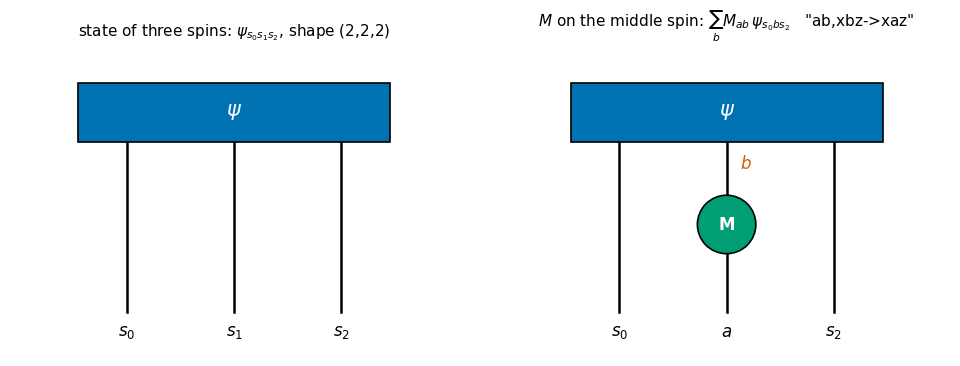

In [32]:
# ==============================================================================
# FIGURE: a 3-spin state as a tensor with three legs; a 2x2 matrix attached to the middle leg
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, with_M in zip(axes, (False, True)):
    ax.set_xlim(-2.3, 2.3); ax.set_ylim(-2.2, 1.0); ax.set_aspect("equal"); ax.axis("off")
    ax.add_patch(plt.Rectangle((-1.6, 0.0), 3.2, 0.6, facecolor=C_BLUE, edgecolor="k", lw=1.2, zorder=3))
    ax.text(0, 0.3, r"$\psi$", ha="center", va="center", fontsize=15, color="w", zorder=4)
    for xq, lab in ((-1.1, "$s_0$"), (1.1, "$s_2$")):
        draw_leg(ax, (xq, 0.0), (xq, -1.75), lab, open_end=True)
    if with_M:
        draw_leg(ax, (0, 0.0), (0, -0.55), "b", offset=(0.2, 0.05))
        draw_node(ax, 0, -0.85, "M", C_GREEN)
        draw_leg(ax, (0, -1.15), (0, -1.75), "a", open_end=True)
    else:
        draw_leg(ax, (0, 0.0), (0, -1.75), "$s_1$", open_end=True)
axes[0].set_title(r"state of three spins: $\psi_{s_0 s_1 s_2}$, shape (2,2,2)", fontsize=11)
axes[1].set_title(r'$M$ on the middle spin: $\sum_b M_{ab}\,\psi_{s_0 b s_2}$   "ab,xbz->xaz"', fontsize=11)
plt.tight_layout()
plt.show()

In [33]:
# ==============================================================================
# THREE SPINS: flip the middle one -- index contraction vs the textbook 8x8 matrix
# ==============================================================================
up, down = np.array([1.0, 0.0]), np.array([0.0, 1.0])
sx = np.array([[0.0, 1.0], [1.0, 0.0]])                 # Pauli sigma^x
id2 = np.eye(2)

# --- a basis state: |up, up, down> = |0 0 1> ------------------------------------------------------
psi = np.einsum(outer_string(3), up, up, down)          # product state = outer product, shape (2,2,2)
print("|001>: non-zero amplitude at multi-index", tuple(int(s[0]) for s in np.nonzero(psi)),
      "= flat index", int(np.flatnonzero(psi.reshape(-1))[0]))
psi_flipped = apply_matrix_to_axis(psi, sx, 1)          # builds and uses 'db,abc->adc'
print("after sigma^x on spin 1:              ", tuple(int(s[0]) for s in np.nonzero(psi_flipped)),
      "= flat index", int(np.flatnonzero(psi_flipped.reshape(-1))[0]), " i.e. |011>")

# --- a generic (random complex, normalized) state: all three positions against the dense Kronecker product ---
psi = rng.normal(size=(2, 2, 2)) + 1j * rng.normal(size=(2, 2, 2))
psi /= np.linalg.norm(psi)
dense = {0: np.kron(np.kron(sx, id2), id2), 1: np.kron(np.kron(id2, sx), id2), 2: np.kron(np.kron(id2, id2), sx)}
for q in range(3):
    matrix_free = apply_matrix_to_axis(psi, sx, q).reshape(8)       # one small contraction
    textbook = dense[q] @ psi.reshape(8)                            # 8x8 matrix times 8-vector
    check(f"sigma^x on spin {q}: '{axis_string(3, q)}' vs kron chain", matrix_free, textbook)

|001>: non-zero amplitude at multi-index (0, 0, 1) = flat index 1
after sigma^x on spin 1:               (0, 1, 1) = flat index 3  i.e. |011>
sigma^x on spin 0: 'da,abc->dbc' vs kron chain       max|diff| = 0.0e+00
sigma^x on spin 1: 'db,abc->adc' vs kron chain       max|diff| = 0.0e+00
sigma^x on spin 2: 'dc,abc->abd' vs kron chain       max|diff| = 0.0e+00


The basis state $|001\rangle$ (flat index $1$) became $|011\rangle$ (flat index $3=(011)_2$): the middle bit was flipped. For a generic state and for each of the three
positions, the small contraction reproduces the $8\times8$ Kronecker-product matrix exactly. For 3 spins the saving is irrelevant; for 30 spins the
dense matrix would need $4^{30}\approx10^{18}$ entries, while the contraction still touches each of the $2^{30}$ amplitudes only twice.

Finally, here is the first function of the course's simulation engine that you can now read in full. It builds product states exactly the way we did, with a
programmatically assembled outer-product string (the characters `'0'`, `'1'` denote $|{\uparrow}\rangle$, $|{\downarrow}\rangle$; `'+'`, `'-'` are the
eigenstates of $\sigma^x$, and `'r'`, `'l'` those of $\sigma^y$):

In [34]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)


# ------------------------------------------------------------------------------
# CHECKPOINT: the engine function against our own outer product
# ------------------------------------------------------------------------------
plus = np.array([1.0, 1.0]) / np.sqrt(2)                # |+> = (|0> + |1>)/sqrt(2)
check("engine product_state('0+1') vs einsum(outer_string(3), up, plus, down)",
      product_state("0+1"), np.einsum(outer_string(3), up, plus, down), tol=TOL * 10)
print("shape:", product_state("0+1").shape, "| dtype:", product_state("0+1").dtype)

engine product_state('0+1') vs einsum(outer_string(3), up, plus, down) max|diff| = 0.0e+00


shape: (2, 2, 2) | dtype: complex128


In notebook [05_matrix_free_operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) our `apply_matrix_to_axis` will grow into the engine's central routine, which applies operators to
one *or several* spins at once (Exercise 7 lets you take that step yourself), and the partial-trace builder of Section 14.3 returns in
[06_states_observables_entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb).

## 17. Summary -- key takeaways

* **einsum = index notation that runs.** Three rules: a letter missing from the output is summed; a letter in the output is a free index (and the output order is yours to choose);
  the same letter in several places ties those axes together. All of it is nested loops: our `naive_einsum` does the same job in 25 lines.
* **einsum never conjugates.** Bras need an explicit `.conj()`.
* **C-ordering**: the last index runs fastest, flat index $k=\sum_m i_m\prod_{l>m}d_l$. For spins, the multi-index is the binary representation of $k$ with spin 0 as the most significant bit.
* **`reshape` regroups, `transpose` permutes.** Reshape merges *adjacent* indices into a composite index (or splits one) and never moves data; to merge non-adjacent indices, transpose first.
* **A matrix on a composite system is a tensor**: $M_{(ab),(cd)}=T_{abcd}$ (rows first, then columns). Kronecker product = outer product + index permutation + reshape, `"ab,cd->acbd"`;
  partial trace = repeated letter inside one operand, `"abcb->ac"`.
* **Never build $A\otimes\mathbb 1$**: an operator on one subsystem is a contraction with that subsystem's index, cost $\sim 2\cdot2^N$ instead of $4^N$.
* **Cost of a contraction** = product of the lengths of all distinct letters. With several tensors the *order* of pairwise contractions matters ($n^3$ vs $n^2$ for $ABv$); keep the big tensor as one operand and feed small matrices into it.
* **Strings can be built by code** (letters in lists, fresh letters for new indices). In JAX the string is static, the arrays are traced: `jit` compiles a whole sequence of contractions, `vmap` adds batch indices, `grad` differentiates through them.

| operation | formula | einsum string |
|---|---|---|
| matrix-vector | $y_i=\sum_jA_{ij}x_j$ | `"ij,j->i"` |
| matrix-matrix | $C_{ik}=\sum_jA_{ij}B_{jk}$ | `"ij,jk->ik"` |
| inner product | $\sum_ia_i^*b_i$ | `"i,i->"` with `a.conj()` |
| outer product | $a_ib_j$ | `"i,j->ij"` |
| trace / diagonal | $\sum_iA_{ii}$ / $A_{ii}$ | `"ii->"` / `"ii->i"` |
| transpose / permutation | $B_{kij}=T_{ijk}$ | `"ijk->kij"` |
| Hadamard product | $A_{ij}B_{ij}$ | `"ij,ij->ij"` |
| $\mathrm{Tr}(ABC)$ | $\sum_{ijk}A_{ij}B_{jk}C_{ki}$ | `"ij,jk,ki->"` |
| batched matmul | $\sum_jA_{\beta ij}B_{\beta jk}$ | `"bij,bjk->bik"` |
| Kronecker product | $A_{ab}B_{cd}$ | `"ab,cd->acbd"` + reshape |
| $(A\otimes B)v$ without $A\otimes B$ | $\sum_{bd}A_{ab}B_{cd}V_{bd}$ | `"ab,cd,bd->ac"` |
| partial traces | $\sum_bT_{abcb}$, $\sum_aT_{abad}$ | `"abcb->ac"`, `"abad->bd"` |
| matrix on the middle index | $\sum_bM_{ab}T_{xbz}$ | `"ab,xbz->xaz"` |

## 18. Exercises

Each exercise comes with a **checker** that tests your answer with `assert`s on random data. Replace `None` by your answer and run the cell: it prints `PASSED` or
raises an `AssertionError` telling you what went wrong. As long as the answer is `None`, the cell only reports "not attempted", so the notebook still runs from top to bottom.
Solutions are collected in Section 20 at the very end -- try each exercise yourself before you look. Difficulty: ★ warm-up, ★★ requires thought, ★★★ a small project.

In [35]:
# ==============================================================================
# EXERCISE RUNNER
# ==============================================================================
def run_exercise(number, answer, checker):
    """Run `checker(answer)` (which asserts correctness) unless the exercise has not been attempted yet."""
    if answer is None:
        print(f"Exercise {number}: not attempted yet (replace None by your answer).")
        return
    checker(answer)
    print(f"Exercise {number}: PASSED")

**Exercise 1 (★) -- five strings.** For $n\times n$ matrices $A,B$ and a batch of vectors $X_{\beta i}$ write the einsum strings for
(a) the column sums $c_j=\sum_iA_{ij}$; (b) the product $A^TB$, i.e. $\sum_kA_{ki}B_{kj}$; (c) the squared Frobenius norm $\sum_{ij}A_{ij}^2$ (two operands, both `A`);
(d) the diagonal of the product, $d_i=\sum_jA_{ij}B_{ji}$, *without* computing the off-diagonal entries of $AB$; (e) the squared norms of all vectors in the batch, $n_\beta=\sum_iX_{\beta i}^2$ (two operands, both `X`).
What is the cost of (d) compared with `np.diag(A @ B)`?

In [36]:
def check_ex1(strings):
    A_, B_, X_ = rng.normal(size=(5, 5)), rng.normal(size=(5, 5)), rng.normal(size=(7, 5))
    refs = {"a": ((A_,), A_.sum(axis=0)), "b": ((A_, B_), A_.T @ B_), "c": ((A_, A_), np.linalg.norm(A_) ** 2),
            "d": ((A_, B_), np.diag(A_ @ B_)), "e": ((X_, X_), np.linalg.norm(X_, axis=1) ** 2)}
    for key, (ops, ref) in refs.items():
        got = np.einsum(strings[key], *ops)
        assert got.shape == np.shape(ref), f"({key}): wrong output shape {got.shape}"
        assert np.allclose(got, ref), f"({key}): wrong numbers"
        if key == "d":
            assert len(set(strings[key]) - set(",->")) == 2, "(d): use only two distinct letters -> cost n^2, not n^3"


ex1_answer = None      # e.g. {"a": "ij->j", "b": "...", "c": "...", "d": "...", "e": "..."}
run_exercise(1, ex1_answer, check_ex1)

Exercise 1: not attempted yet (replace None by your answer).


**Exercise 2 (★) -- from the flat index back to the multi-index.** Write `multi_from_flat(k, shape)`, the inverse of `flat_from_multi` of Section 5.2, using only integer division and
remainder (`divmod`). Hint: the *last* index is `k % d_last`. For shape `(2,)*N` your function converts a number to its $N$ binary digits.

In [37]:
def check_ex2(multi_from_flat):
    for shape_ in [(2, 3, 4), (5, 1, 3, 2), (2,) * 6]:
        for k_ in range(int(np.prod(shape_))):
            got = tuple(int(i) for i in multi_from_flat(k_, shape_))
            assert got == tuple(int(i) for i in np.unravel_index(k_, shape_)), f"shape {shape_}, k={k_}: got {got}"
            assert flat_from_multi(got, shape_) == k_


ex2_answer = None      # a function:  def multi_from_flat(k, shape): ...
run_exercise(2, ex2_answer, check_ex2)

Exercise 2: not attempted yet (replace None by your answer).


**Exercise 3 (★★) -- reshape or transpose?** A tensor `T` has shape `(2,3,4)` with indices $(i,j,k)$. Write a function that returns the $(8,3)$ **matrix** $Q_{(ik),j}=T_{ijk}$ whose row index is the
composite of the *first and the last* index, $I=4i+k$. (Which of the two operations of Section 5 do you need first?)

In [38]:
def check_ex3(merge_first_last):
    T_ = rng.normal(size=(2, 3, 4))
    Q = merge_first_last(T_)
    assert Q.shape == (8, 3), f"wrong shape {Q.shape}"
    for i_, j_, k_ in itertools.product(range(2), range(3), range(4)):
        assert Q[4 * i_ + k_, j_] == T_[i_, j_, k_], "wrong entry: a bare reshape does not bring i and k together"


ex3_answer = None      # a function:  def merge_first_last(T): ...
run_exercise(3, ex3_answer, check_ex3)

Exercise 3: not attempted yet (replace None by your answer).


**Exercise 4 (★★) -- partial transpose.** For a matrix $M$ on a composite space $(d_A,d_B)$ the *partial transpose* with respect to $B$ swaps the row and column index of subsystem $B$ only:
$\big(M^{T_B}\big)_{(ab),(cd)}=M_{(ad),(cb)}$. Implement `partial_transpose_B(M, dA, dB)` with one reshape, one einsum and one reshape. For product operators it must give
$(A\otimes B)^{T_B}=A\otimes B^T$. (The partial transpose is the key to detecting entanglement in mixed states; it returns in
[25 — entanglement negativity](../ch09_entanglement_and_complexity/25_entanglement_negativity.ipynb).)

In [39]:
def check_ex4(partial_transpose_B):
    dA_, dB_ = 2, 3
    A1_, A2_ = rng.normal(size=(2, dA_, dA_))
    B1_, B2_ = rng.normal(size=(2, dB_, dB_))
    M_ = np.kron(A1_, B1_) + np.kron(A2_, B2_)
    ref = np.kron(A1_, B1_.T) + np.kron(A2_, B2_.T)
    got = partial_transpose_B(M_, dA_, dB_)
    assert got.shape == ref.shape and np.allclose(got, ref), "wrong result (did you transpose A as well?)"
    assert np.allclose(partial_transpose_B(got, dA_, dB_), M_), "applying it twice must give back M"


ex4_answer = None      # a function:  def partial_transpose_B(M, dA, dB): ...
run_exercise(4, ex4_answer, check_ex4)

Exercise 4: not attempted yet (replace None by your answer).


**Exercise 5 (★★) -- cost counter.** Write `contraction_cost(subscripts, *shapes)` that returns the number of innermost loop iterations of `naive_einsum`: the product of the lengths of all
distinct letters. Then use it to answer: for `"ij,jk,kl,l->i"` with $n=100$, what is the cost of the literal evaluation, and what is the total cost of the best sequence of pairwise contractions?

In [40]:
def check_ex5(contraction_cost):
    assert contraction_cost("ij,j->i", (10, 20), (20,)) == 200
    assert contraction_cost("ij,jk->ik", (10, 20), (20, 30)) == 6000
    assert contraction_cost("abcb->ac", (2, 3, 2, 3)) == 12
    assert contraction_cost("ab,xbz->xaz", (2, 2), (2, 2, 2)) == 16
    assert contraction_cost("ij,jk,kl,l->i", *[(100, 100)] * 3, (100,)) == 100 ** 4


ex5_answer = None      # a function:  def contraction_cost(subscripts, *shapes): ...
run_exercise(5, ex5_answer, check_ex5)

Exercise 5: not attempted yet (replace None by your answer).


**Exercise 6 (★★, physics) -- the singlet.** Two spins-1/2 in the state $\psi_{s_0s_1}$ (a $(2,2)$ array). (a) Write `expect_op_spin0(psi, O)` that returns
$\langle\psi|\,O\otimes\mathbb 1\,|\psi\rangle=\sum_{a,c,b}\psi^*_{ab}\,O_{ac}\,\psi_{cb}$ as **one** einsum, without `np.kron`. (b) Write `reduced_matrix_spin0(psi)` that returns the $2\times2$ matrix
$\rho_{ac}=\sum_b\psi_{ab}\psi^*_{cb}$. Evaluate both for the singlet $(|{\uparrow\downarrow}\rangle-|{\downarrow\uparrow}\rangle)/\sqrt2$ and for the product state $|{\uparrow\downarrow}\rangle$, with $O=\sigma^z$.
Interpret: what does spin 0 "look like" if spin 1 is ignored? (The matrix $\rho$ is the *reduced density matrix*, the subject of notebook 06, and $\langle O\rangle=\mathrm{Tr}(\rho\,O)$.)

In [41]:
def check_ex6(functions):
    expect_op_spin0, reduced_matrix_spin0 = functions
    psi_ = rng.normal(size=(2, 2)) + 1j * rng.normal(size=(2, 2))
    psi_ /= np.linalg.norm(psi_)
    O_ = rng.normal(size=(2, 2)) + 1j * rng.normal(size=(2, 2))
    ref = np.vdot(psi_.reshape(4), np.kron(O_, np.eye(2)) @ psi_.reshape(4))
    assert np.allclose(expect_op_spin0(psi_, O_), ref), "expectation value differs from the dense <psi|O(x)1|psi> (conjugate?)"
    rho_ = reduced_matrix_spin0(psi_)
    assert rho_.shape == (2, 2) and np.allclose(rho_, rho_.conj().T) and np.isclose(np.trace(rho_), 1.0)
    assert np.allclose(np.trace(rho_ @ O_), ref), "Tr(rho O) must reproduce the expectation value"
    singlet_ = np.array([[0, 1], [-1, 0]]) / np.sqrt(2)
    assert np.allclose(reduced_matrix_spin0(singlet_), np.eye(2) / 2)


ex6_answer = None      # a tuple of two functions: (expect_op_spin0, reduced_matrix_spin0)
run_exercise(6, ex6_answer, check_ex6)

Exercise 6: not attempted yet (replace None by your answer).


**Exercise 7 (★★★, extend the code) -- a matrix on two axes.** Generalize Section 14.2: write `two_axis_string(n, q1, q2)` and `apply_matrix_to_two_axes(T, M4, q1, q2)` for a
$4\times4$ matrix acting on the (not necessarily adjacent) axes $q_1,q_2$ of a tensor of shape $(2,)^n$. Steps: reshape `M4` to $U_{a_1a_2b_1b_2}$ (Section 7: rows first, then columns; $q_1$ belongs to
the more significant digit); take two fresh letters; $U$ carries (new$_1$, new$_2$, old$_{q_1}$, old$_{q_2}$); in the output the letters at positions $q_1,q_2$ are replaced by the new ones.
For $n=4$, $(q_1,q_2)=(1,3)$ you should obtain `"efbd,abcd->aecf"`. The checker compares with an independent route (move the two axes to the front, reshape to a $(4,\text{rest})$ matrix, multiply, undo), including $q_1>q_2$.

In [42]:
def check_ex7(apply_matrix_to_two_axes):
    n_ = 4
    T_ = rng.normal(size=(2,) * n_)
    M4_ = rng.normal(size=(4, 4))
    for q1_, q2_ in [(0, 1), (1, 2), (1, 3), (0, 3), (3, 1), (2, 0)]:
        moved = np.moveaxis(T_, (q1_, q2_), (0, 1))                       # reference: bring q1,q2 to the front ...
        ref = (M4_ @ moved.reshape(4, -1)).reshape((2,) * n_)             # ... composite index (q1,q2), ordinary matmul ...
        ref = np.moveaxis(ref, (0, 1), (q1_, q2_))                        # ... and put the axes back
        got = apply_matrix_to_two_axes(T_, M4_, q1_, q2_)
        assert got.shape == ref.shape and np.allclose(got, ref), f"wrong result for (q1,q2)=({q1_},{q2_})"


ex7_answer = None      # a function:  def apply_matrix_to_two_axes(T, M4, q1, q2): ...
run_exercise(7, ex7_answer, check_ex7)

Exercise 7: not attempted yet (replace None by your answer).


**Exercise 8 (★★, JAX) -- one compiled contraction instead of a Python loop.** The "average magnetization along $x$" of a real, **normalized** tensor $T$ of shape $(2,)^n$ ($n$ spins) is
$m=\frac1n\sum_{q}\langle T|\sigma^x_q|T\rangle$, where $\sigma^x_q$ acts on axis $q$. Write `mean_sx(T)` with `jnp.einsum`, reusing `axis_string`, decorate it with `jax.jit`, and measure
compile time and run time separately for $n=16$ as in Section 15. (No checker for the timing; the checker tests the value for the uniform tensor $T\propto1$, for which $m=1$, and for a basis state, for which $m=0$.)

In [43]:
def check_ex8(mean_sx):
    n_ = 6
    uniform = jnp.ones((2,) * n_, dtype=RDTYPE) / jnp.sqrt(2.0 ** n_)
    basis = jnp.zeros((2,) * n_, dtype=RDTYPE).at[(0,) * n_].set(1.0)
    assert abs(float(mean_sx(uniform)) - 1.0) < 10 * TOL, "uniform tensor: every spin points along +x, m must be 1"
    assert abs(float(mean_sx(basis))) < 10 * TOL, "basis state |00..0>: <sigma^x> = 0 on every spin"


ex8_answer = None      # a function:  def mean_sx(T): ...
run_exercise(8, ex8_answer, check_ex8)

Exercise 8: not attempted yet (replace None by your answer).


## 19. References

1. A. Einstein, *Die Grundlage der allgemeinen Relativitätstheorie*, Annalen der Physik (4th series) **49**, 769-822 (1916); in the publisher's
   continuous numbering vol. **354**, DOI 10.1002/andp.19163540702 -- the paper that introduced the summation convention.
2. C. R. Harris *et al.*, *Array programming with NumPy*, Nature **585**, 357 (2020) -- arrays, strides, views, broadcasting.
3. J. Bradbury *et al.*, *JAX: composable transformations of Python+NumPy programs* (2018), software available at https://github.com/jax-ml/jax ; see the `jax.numpy.einsum` documentation.
4. D. G. A. Smith and J. Gray, *opt_einsum -- A Python package for optimizing contraction order for einsum-like expressions*, Journal of Open Source Software **3**(26), 753 (2018) -- the contraction-path optimizer used by `jnp.einsum`; the same optimization was contributed upstream to NumPy, where `optimize=True` selects its greedy variant.
5. R. Penrose, *Applications of negative dimensional tensors*, in *Combinatorial Mathematics and its Applications*, ed. D. J. A. Welsh (Academic Press, 1971), pp. 221-244 -- the origin of the diagrammatic notation.
6. J. C. Bridgeman and C. T. Chubb, *Hand-waving and interpretive dance: an introductory course on tensor networks*, J. Phys. A: Math. Theor. **50**, 223001 (2017) -- tensor diagrams and contraction costs for beginners.
7. R. Orús, *A practical introduction to tensor networks: Matrix product states and projected entangled pair states*, Annals of Physics **349**, 117 (2014).
8. M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000; 10th anniversary edition 2010, DOI 10.1017/CBO9780511976667) -- tensor products (Sec. 2.1.7) and the reduced density operator / partial trace (Sec. 2.4.3).

## 20. Solutions to the exercises

Every solution is passed through the same checker as above, so this section doubles as a test of the checkers.

In [44]:
# ==============================================================================
# SOLUTIONS 1-3
# ==============================================================================
# --- Exercise 1 ---  (d) uses two letters only: cost n^2, whereas np.diag(A @ B) computes all n^2 entries of AB at cost n^3
sol1 = {"a": "ij->j", "b": "ki,kj->ij", "c": "ij,ij->", "d": "ij,ji->i", "e": "bi,bi->b"}
run_exercise(1, sol1, check_ex1)


# --- Exercise 2 ---  peel off the digits from the right: the last index is the remainder modulo the last dimension
def multi_from_flat_solution(k, shape):
    multi = []
    for d in reversed(shape):
        k, i = divmod(k, d)            # k <- k // d,  i <- k % d
        multi.append(i)
    return tuple(reversed(multi))


run_exercise(2, multi_from_flat_solution, check_ex2)
print("   example: 45 in binary with 6 digits ->", multi_from_flat_solution(45, (2,) * 6), f"= {45:06b}")


# --- Exercise 3 ---  transpose first (bring i and k next to each other), reshape second
def merge_first_last_solution(T):
    return np.einsum("ijk->ikj", T).reshape(T.shape[0] * T.shape[2], T.shape[1])


run_exercise(3, merge_first_last_solution, check_ex3)

Exercise 1: PASSED
Exercise 2: PASSED
   example: 45 in binary with 6 digits -> (1, 0, 1, 1, 0, 1) = 101101
Exercise 3: PASSED


In [45]:
# ==============================================================================
# SOLUTIONS 4-6
# ==============================================================================
# --- Exercise 4 ---  T[a,b,c,d] -> T[a,d,c,b]: swap the two B-letters, leave the A-letters alone
def partial_transpose_B_solution(M, dA, dB):
    T = M.reshape(dA, dB, dA, dB)
    return np.einsum("abcd->adcb", T).reshape(dA * dB, dA * dB)


run_exercise(4, partial_transpose_B_solution, check_ex4)


# --- Exercise 5 ---
def contraction_cost_solution(subscripts, *shapes):
    inputs = subscripts.split("->")[0].split(",")
    size = {}
    for labels, shape_ in zip(inputs, shapes):
        size.update(zip(labels, shape_))
    return int(np.prod([size[l] for l in size]))


run_exercise(5, contraction_cost_solution, check_ex5)
n_ = 100
literal = contraction_cost_solution("ij,jk,kl,l->i", *[(n_, n_)] * 3, (n_,))
pairwise = 3 * contraction_cost_solution("kl,l->k", (n_, n_), (n_,))      # right to left: three matrix-vector products
print(f"   'ij,jk,kl,l->i', n={n_}: literal {literal:.1e} iterations, best pairwise order (right to left) {pairwise:.1e}")


# --- Exercise 6 ---
def expect_op_spin0_solution(psi, O):
    return np.einsum("ab,ac,cb->", psi.conj(), O, psi)


def reduced_matrix_spin0_solution(psi):
    return np.einsum("ab,cb->ac", psi, psi.conj())


run_exercise(6, (expect_op_spin0_solution, reduced_matrix_spin0_solution), check_ex6)
sz = np.diag([1.0, -1.0])
singlet = np.array([[0.0, 1.0], [-1.0, 0.0]]) / np.sqrt(2)               # psi[0,1] = 1/sqrt2, psi[1,0] = -1/sqrt2
up_down = np.einsum("a,b->ab", up, down)
for name, state in (("singlet", singlet), ("|up,down>", up_down)):
    print(f"   {name:<10s}: <sigma^z_0> = {expect_op_spin0_solution(state, sz).real:+.3f},  rho =",
          np.round(reduced_matrix_spin0_solution(state).real, 3).tolist())

Exercise 4: PASSED
Exercise 5: PASSED
   'ij,jk,kl,l->i', n=100: literal 1.0e+08 iterations, best pairwise order (right to left) 3.0e+04
Exercise 6: PASSED
   singlet   : <sigma^z_0> = +0.000,  rho = [[0.5, 0.0], [0.0, 0.5]]
   |up,down> : <sigma^z_0> = +1.000,  rho = [[1.0, 0.0], [0.0, 0.0]]


*Interpretation of Exercise 6.* In the product state spin 0 simply points up: $\rho=|{\uparrow}\rangle\langle{\uparrow}|$ and $\langle\sigma^z_0\rangle=+1$. In the singlet
$\rho=\mathbb 1/2$: looked at alone, spin 0 is *completely random* -- every measurement direction gives $\pm1$ with probability $1/2$ -- although the two-spin state is perfectly well defined.
All the information sits in the correlations between the spins. This is the hallmark of entanglement, quantified in notebook
[06_states_observables_entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb).

In [46]:
# ==============================================================================
# SOLUTIONS 7-8
# ==============================================================================
# --- Exercise 7 ---
def two_axis_string(n, q1, q2):
    inp = list(_LETTERS[:n])
    new1, new2 = _LETTERS[n], _LETTERS[n + 1]
    out = inp.copy()
    out[q1], out[q2] = new1, new2
    return f"{new1}{new2}{inp[q1]}{inp[q2]},{''.join(inp)}->{''.join(out)}"


def apply_matrix_to_two_axes_solution(T, M4, q1, q2):
    U = M4.reshape(2, 2, 2, 2)                          # U[a1,a2,b1,b2]: rows (a1,a2), columns (b1,b2)
    return np.einsum(two_axis_string(T.ndim, q1, q2), U, T)


print("   n=4, (q1,q2)=(1,3):", two_axis_string(4, 1, 3))
assert two_axis_string(4, 1, 3) == "efbd,abcd->aecf"
run_exercise(7, apply_matrix_to_two_axes_solution, check_ex7)


# --- Exercise 8 ---
@jax.jit
def mean_sx_solution(T):
    sx_j = jnp.array([[0.0, 1.0], [1.0, 0.0]], dtype=T.dtype)
    n = T.ndim
    total = 0.0
    for q in range(n):                                  # static Python loop, unrolled at trace time
        total = total + jnp.vdot(T, jnp.einsum(axis_string(n, q), sx_j, T))
    return total / n


run_exercise(8, mean_sx_solution, check_ex8)
T16 = jnp.asarray(rng.normal(size=(2,) * 16), dtype=RDTYPE)
T16 = T16 / jnp.linalg.norm(T16)
t0 = time.perf_counter()
m16 = float(mean_sx_solution(T16))
t_first = time.perf_counter() - t0
print(f"   n=16, random tensor: m = {m16:+.5f} | first call (compile+run) {t_first * 1e3:.1f} ms | later calls "
      f"{best_time(mean_sx_solution, T16) * 1e3:.2f} ms")

   n=4, (q1,q2)=(1,3): efbd,abcd->aecf
Exercise 7: PASSED


Exercise 8: PASSED


   n=16, random tensor: m = -0.00010 | first call (compile+run) 282.8 ms | later calls 2.21 ms


---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/